# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
# Used minicoda to setup local environment to match recommended versions


In [2]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:",plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

#df = pd.read_parquet('E:\\GitRepo\\eda_nyc_taxi\\Data\\trip_records\\2023-1.parquet')
#df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')


# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('E:\\GitRepo\\eda_nyc_taxi\\Data\\trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)
        print(f"file_path: {file_path}")
        # Reading the current file
        monthly_df = pd.read_parquet(file_path)

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for adate in monthly_df['tpep_pickup_datetime'].dt.date.unique():
            date_df = monthly_df[monthly_df['tpep_pickup_datetime'].dt.date == adate]
            #print(f"date: {adate}")
            # Iterate through each hour of the selected date
            for hour in  date_df['tpep_pickup_datetime'].dt.hour.unique():
                hour_data = date_df[date_df['tpep_pickup_datetime'].dt.hour == hour]

                # Sample 5% of the hourly data randomly
                sample = hour_data.sample(frac = 0.05, random_state = 42)

                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sample])

        # Concatenate the sampled data of all the dates to a single dataframe
        df =pd.concat([df, sampled_data])

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [7]:
# Store the df in csv/parquet
#df.to_parquet('sample_nyc_taxi.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [8]:
# Load the new data file
import os

# Select the folder having data files
os.chdir('E:\\GitRepo\\eda_nyc_taxi\\Data\\trip_records')

df = pd.read_parquet('sample_nyc_taxi.parquet')

In [9]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3192,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
2995263,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896400 entries, 428 to 2698522
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            fl

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [11]:
# Fix the index and drop any columns that are not needed

df.reset_index(drop=True,inplace=True)

In [12]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [13]:
df[(df['airport_fee'] > 0) & (df['Airport_fee'] > 0)] #No rows where data is populated in both columns

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee


In [14]:
#Identify the file reason for duplicate column
df[(df['airport_fee'] > 0)]['tpep_pickup_datetime'].dt.month.unique()
#This indicates that January month file is origin for this issue and to confirm the same verified the structure of the January file(2023-1.parquet). 

array([1])

In [15]:

#Check if any January month data has any data populated in Airport_fee column. If not we can safely combine the columns
df[(~df['Airport_fee'].isna()) & (df['tpep_pickup_datetime'].dt.month==1)]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee


In [16]:
# Combine the two airport fee columns
df.loc[df['Airport_fee'].isna(), 'Airport_fee'] = df['airport_fee']
df.drop(columns=['airport_fee'], inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [18]:
# check where values of fare amount are negative
df[~(df['fare_amount']>=0)]

#There are no records with negatie fare ammount

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [19]:
# Analyse RatecodeID for the negative fare amounts

#There are no records with negative fare ammount. Anyhow in general there are records with RatecodeID=99 and there is no such category defined as part of the documenation provided.

In [20]:
# Find which columns have negative values

numerical_cols=['passenger_count','trip_distance','fare_amount','extra','mta_tax','tip_amount','tolls_amount','improvement_surcharge','total_amount','congestion_surcharge','Airport_fee']

def find_cols_with_negative_values(df, cols_list):
    min_vals = df[numerical_cols].min()
    cols_with_negative_values = min_vals[min_vals < 0].index.tolist()
    return cols_with_negative_values

cols_with_negative_values = find_cols_with_negative_values(df, numerical_cols)
cols_with_negative_values
#Here are the columns with nagitive values.
#extra, mta_tax, improvement_surcharge, total_amount, congestion_surcharge, Airport_fee


['extra',
 'mta_tax',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

In [21]:
# fix these negative values

#described columns with nagitive values to check states to look for suitable value to correct with
df[cols_with_negative_values].describe()


,extra,mta_tax,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.831526e+06,1.831526e+06
mean,1.588018e+00,4.952796e-01,9.989706e-01,2.898186e+01,2.307524e+00,1.428976e-01
std,1.829200e+00,4.885128e-02,3.112072e-02,1.064162e+02,6.667267e-01,4.648725e-01
min,-2.500000e+00,-5.000000e-01,-1.000000e+00,-5.750000e+00,-2.500000e+00,-1.750000e+00
25%,0.000000e+00,5.000000e-01,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,1.000000e+00,5.000000e-01,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.500000e+00,5.000000e-01,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00
max,2.080000e+01,4.000000e+00,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00


In [22]:
#Identify the records with negative values for each column along with no of records
neg_counts = {
    col: df[col][df[col]<0].value_counts()
    for col in cols_with_negative_values
}
neg_df = (
    pd.concat(neg_counts, axis=0)
      .reset_index()
      .rename(columns={'level_0':'column_name','level_1':'negative_value',0:'record_count'})
)
neg_df


,column_name,negative_value,count
0,extra,-1.00,2
1,extra,-2.50,1
2,mta_tax,-0.50,73
3,improvement_surcharge,-1.00,78
4,total_amount,-4.00,45
5,total_amount,-1.50,12
6,total_amount,-3.25,7
7,total_amount,-5.25,3
8,total_amount,-5.75,3
9,total_amount,-3.50,3


In [23]:
#Looking at the above result trying to convert negative values to positive
df[cols_with_negative_values] = df[cols_with_negative_values].abs()

In [24]:
#Check and make sure no columns left with negative values
cols_with_negative_values = find_cols_with_negative_values(df, numerical_cols)
cols_with_negative_values

[]

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [25]:
# Find the proportion of missing values in each column

#Function to find missing value proportation
def missing_values_proportation(df):
    missing_values = pd.DataFrame({
        "total_record_count": df.shape[0],
        "missing_record_count": df.isna().sum(),
        "missing_percentage": round(df.isna().mean() * 100,2)
    })
    return missing_values.sort_values(by='missing_percentage', ascending=False)

missing_values_proportation(df)

#Here are the columns with missing values
    #-->Airport_fee
    #-->congestion_surcharge
    #-->passenger_count
    #-->RatecodeID
    #-->store_and_fwd_flag


,total_record_count,missing_record_count,missing_percentage
Airport_fee,1896400,64874,3.42
congestion_surcharge,1896400,64874,3.42
passenger_count,1896400,64874,3.42
RatecodeID,1896400,64874,3.42
store_and_fwd_flag,1896400,64874,3.42
extra,1896400,0,0.00
total_amount,1896400,0,0.00
improvement_surcharge,1896400,0,0.00
tolls_amount,1896400,0,0.00
tip_amount,1896400,0,0.00


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [26]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'

df[(df['passenger_count'].isna())]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,NaN
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,NaN
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,NaN,4.52,NaN,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,NaN
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,NaN,9.19,NaN,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,NaN
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,NaN,2.74,NaN,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896313,1,2023-09-30 22:47:00,2023-09-30 22:59:51,NaN,0.00,NaN,None,68,170,0,17.91,0.0,0.5,0.00,0.00,1.0,21.91,NaN,NaN
1896345,2,2023-09-30 22:26:44,2023-09-30 22:39:41,NaN,2.32,NaN,None,239,50,0,15.93,0.0,0.5,2.00,0.00,1.0,21.93,NaN,NaN
1896356,1,2023-09-30 22:07:52,2023-09-30 22:13:26,NaN,0.00,NaN,None,238,238,0,7.83,0.0,0.5,0.00,0.00,1.0,11.83,NaN,NaN
1896368,2,2023-09-30 22:50:39,2023-09-30 22:56:04,NaN,0.59,NaN,None,142,48,0,16.32,0.0,0.5,3.70,0.00,1.0,24.02,NaN,NaN


In [27]:
#Function to get stats for a list of columns from a df
#This function considers only numerical columns
def getStats(df, column_list):
    result = pd.DataFrame({
            'Mean': round(df[column_list].mean(numeric_only=True),2),
            'Median': round(df[column_list].median(numeric_only=True),2),
            'Mode': df[column_list].mode(numeric_only=True).iloc[0]
        })
    return result

column_list=['passenger_count','congestion_surcharge','Airport_fee']
getStats(df,column_list)

,Mean,Median,Mode
passenger_count,1.37,1.0,1.0
congestion_surcharge,2.31,2.5,2.5
Airport_fee,0.14,0.0,0.0


In [28]:
df['passenger_count'] = df['passenger_count'].fillna(value=round(df['passenger_count'].median(),0))

Did you find zeroes in passenger_count? Handle these.

In [29]:
df['passenger_count'].unique()

array([1., 2., 3., 4., 6., 5., 0., 8., 7., 9.])

In [30]:
df[df['passenger_count']<=0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
118,2,2023-01-01 00:47:28,2023-01-01 00:47:32,0.0,0.0,5.0,N,232,232,1,14.0,0.0,0.0,0.00,0.0,1.0,15.00,0.0,0.0
192,1,2023-01-01 00:50:09,2023-01-01 01:14:29,0.0,3.0,1.0,N,237,90,1,22.6,3.5,0.5,6.90,0.0,1.0,34.50,2.5,0.0
197,1,2023-01-01 00:23:01,2023-01-01 00:32:42,0.0,2.4,1.0,N,43,166,1,12.8,3.5,0.5,2.20,0.0,1.0,20.00,2.5,0.0
234,1,2023-01-01 00:42:48,2023-01-01 00:52:02,0.0,1.0,1.0,N,162,161,1,10.0,3.5,0.5,1.50,0.0,1.0,16.50,2.5,0.0
235,1,2023-01-01 00:58:49,2023-01-01 01:04:32,0.0,0.7,1.0,N,186,234,1,6.5,3.5,0.5,2.30,0.0,1.0,13.80,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896048,1,2023-09-30 21:50:33,2023-09-30 22:31:11,0.0,9.1,1.0,N,142,181,1,44.3,3.5,0.5,9.85,0.0,1.0,59.15,2.5,0.0
1896148,1,2023-09-30 22:11:42,2023-09-30 22:30:33,0.0,3.0,1.0,N,140,48,1,17.0,3.5,0.5,4.40,0.0,1.0,26.40,2.5,0.0
1896244,1,2023-09-30 22:41:29,2023-09-30 22:56:49,0.0,2.2,1.0,N,161,249,1,15.6,3.5,0.5,4.10,0.0,1.0,24.70,2.5,0.0
1896309,1,2023-09-30 22:09:45,2023-09-30 22:14:52,0.0,0.7,1.0,N,142,230,1,6.5,3.5,0.5,2.30,0.0,1.0,13.80,2.5,0.0


In [31]:
df['passenger_count'].value_counts()

passenger_count
1.0    1442098
2.0     277298
3.0      69034
4.0      38537
0.0      29681
5.0      23871
6.0      15860
8.0         11
7.0          5
9.0          5
Name: count, dtype: int64

In [32]:
#Updated passenger_count with median value where passenger_count is 0(zero)
df.loc[df['passenger_count'] == 0, 'passenger_count'] = round(df['passenger_count'].median(),0)

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [33]:
# Fix missing values in 'RatecodeID'
df[df['RatecodeID'].isna()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1.0,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,NaN
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,1.0,10.77,NaN,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,NaN
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,1.0,4.52,NaN,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,NaN
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,1.0,9.19,NaN,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,NaN
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,1.0,2.74,NaN,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896313,1,2023-09-30 22:47:00,2023-09-30 22:59:51,1.0,0.00,NaN,None,68,170,0,17.91,0.0,0.5,0.00,0.00,1.0,21.91,NaN,NaN
1896345,2,2023-09-30 22:26:44,2023-09-30 22:39:41,1.0,2.32,NaN,None,239,50,0,15.93,0.0,0.5,2.00,0.00,1.0,21.93,NaN,NaN
1896356,1,2023-09-30 22:07:52,2023-09-30 22:13:26,1.0,0.00,NaN,None,238,238,0,7.83,0.0,0.5,0.00,0.00,1.0,11.83,NaN,NaN
1896368,2,2023-09-30 22:50:39,2023-09-30 22:56:04,1.0,0.59,NaN,None,142,48,0,16.32,0.0,0.5,3.70,0.00,1.0,24.02,NaN,NaN


In [34]:
df['RatecodeID'].unique().tolist()

[1.0, nan, 2.0, 4.0, 5.0, 99.0, 3.0, 6.0]

In [35]:
df['RatecodeID'].mode()

0    1.0
Name: RatecodeID, dtype: float64

In [36]:
#Updated RatecodeID with mode for the records with no value
df['RatecodeID'] = df['RatecodeID'].fillna(value=df['RatecodeID'].mode()[0])

In [37]:
#Found records where ratecard value is incorrect. Need to standardize or take some action later. 
df[df['RatecodeID']==99]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
372,1,2023-01-01 01:51:10,2023-01-01 02:19:45,1.0,0.0,99.0,N,74,77,1,41.2,0.0,0.5,0.0,6.55,1.0,49.25,0.0,0.0
770,1,2023-01-01 02:30:32,2023-01-01 03:05:47,1.0,10.1,99.0,N,28,86,1,36.5,0.0,0.5,0.0,0.00,1.0,38.00,0.0,0.0
1713,1,2023-01-01 10:11:12,2023-01-01 10:29:27,1.0,0.0,99.0,N,35,77,1,14.0,0.0,0.5,0.0,0.00,1.0,15.50,0.0,0.0
1968,1,2023-01-01 11:39:40,2023-01-01 11:55:59,1.0,2.9,99.0,N,42,47,1,22.5,0.0,0.5,0.0,0.00,1.0,24.00,0.0,0.0
2233,1,2023-01-01 12:55:17,2023-01-01 13:17:08,1.0,2.6,99.0,N,41,167,1,20.5,0.0,0.5,0.0,0.00,1.0,22.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1893013,1,2023-09-30 12:21:00,2023-09-30 13:01:31,1.0,0.9,99.0,N,37,182,1,46.5,0.0,0.5,0.0,0.00,1.0,48.00,0.0,0.0
1893221,1,2023-09-30 13:55:58,2023-09-30 14:20:03,1.0,1.9,99.0,N,232,158,1,18.5,0.0,0.5,0.0,0.00,1.0,20.00,0.0,0.0
1893366,1,2023-09-30 13:52:38,2023-09-30 14:14:49,1.0,2.8,99.0,N,127,116,1,20.5,0.0,0.5,0.0,0.00,1.0,22.00,0.0,0.0
1893380,1,2023-09-30 13:10:13,2023-09-30 14:09:53,1.0,16.8,99.0,N,205,247,1,50.5,0.0,0.5,0.0,6.94,1.0,58.94,0.0,0.0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [38]:
# handle null values in congestion_surcharge
df[df['congestion_surcharge'].isna()]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1.0,19.24,1.0,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,NaN
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,1.0,10.77,1.0,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,NaN
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,1.0,4.52,1.0,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,NaN
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,1.0,9.19,1.0,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,NaN
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,1.0,2.74,1.0,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896313,1,2023-09-30 22:47:00,2023-09-30 22:59:51,1.0,0.00,1.0,None,68,170,0,17.91,0.0,0.5,0.00,0.00,1.0,21.91,NaN,NaN
1896345,2,2023-09-30 22:26:44,2023-09-30 22:39:41,1.0,2.32,1.0,None,239,50,0,15.93,0.0,0.5,2.00,0.00,1.0,21.93,NaN,NaN
1896356,1,2023-09-30 22:07:52,2023-09-30 22:13:26,1.0,0.00,1.0,None,238,238,0,7.83,0.0,0.5,0.00,0.00,1.0,11.83,NaN,NaN
1896368,2,2023-09-30 22:50:39,2023-09-30 22:56:04,1.0,0.59,1.0,None,142,48,0,16.32,0.0,0.5,3.70,0.00,1.0,24.02,NaN,NaN


In [39]:
df['congestion_surcharge'].value_counts()


congestion_surcharge
2.5    1690628
0.0     140897
0.5          1
Name: count, dtype: int64

In [40]:
column_list=['congestion_surcharge']
getStats(df,column_list)

,Mean,Median,Mode
congestion_surcharge,2.31,2.5,2.5


In [41]:
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(value=df['congestion_surcharge'].median())

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [42]:
# Handle any remaining missing values
missing_values_proportation(df)

,total_record_count,missing_record_count,missing_percentage
Airport_fee,1896400,64874,3.42
store_and_fwd_flag,1896400,64874,3.42
fare_amount,1896400,0,0.00
congestion_surcharge,1896400,0,0.00
total_amount,1896400,0,0.00
improvement_surcharge,1896400,0,0.00
tolls_amount,1896400,0,0.00
tip_amount,1896400,0,0.00
mta_tax,1896400,0,0.00
extra,1896400,0,0.00


In [43]:
#Still Airport_fee & store_and_fwd_flag columns have missing values
column_list=['Airport_fee']
getStats(df,column_list)

,Mean,Median,Mode
Airport_fee,0.14,0.0,0.0


In [44]:
df['Airport_fee'].value_counts()

Airport_fee
0.00    1670564
1.75     121134
1.25      39827
1.00          1
Name: count, dtype: int64

In [45]:
df['Airport_fee'] = df['Airport_fee'].fillna(value=df['Airport_fee'].median())

In [46]:
df[df['store_and_fwd_flag'].isna()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1.0,19.24,1.0,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,2.5,0.0
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,1.0,10.77,1.0,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,2.5,0.0
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,1.0,4.52,1.0,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,2.5,0.0
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,1.0,9.19,1.0,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,2.5,0.0
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,1.0,2.74,1.0,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896313,1,2023-09-30 22:47:00,2023-09-30 22:59:51,1.0,0.00,1.0,None,68,170,0,17.91,0.0,0.5,0.00,0.00,1.0,21.91,2.5,0.0
1896345,2,2023-09-30 22:26:44,2023-09-30 22:39:41,1.0,2.32,1.0,None,239,50,0,15.93,0.0,0.5,2.00,0.00,1.0,21.93,2.5,0.0
1896356,1,2023-09-30 22:07:52,2023-09-30 22:13:26,1.0,0.00,1.0,None,238,238,0,7.83,0.0,0.5,0.00,0.00,1.0,11.83,2.5,0.0
1896368,2,2023-09-30 22:50:39,2023-09-30 22:56:04,1.0,0.59,1.0,None,142,48,0,16.32,0.0,0.5,3.70,0.00,1.0,24.02,2.5,0.0


In [47]:
df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    1820287
Y      11239
Name: count, dtype: int64

In [48]:
df['store_and_fwd_flag'].mode()

0    N
Name: store_and_fwd_flag, dtype: object

In [49]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(value=df['store_and_fwd_flag'].mode()[0])

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [50]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
numerical_cols=['passenger_count','trip_distance','fare_amount','extra','mta_tax','tip_amount','tolls_amount','improvement_surcharge','total_amount','congestion_surcharge','Airport_fee']
df[numerical_cols].describe()

#Looking at the data we can clearly see some of the columns unrealistic numbers
#trip_distance, fare_amount, tip_amount, tolls_amount, total_amount anyhow lets try to analyze the same using boxplot for each column

,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06
mean,1.372236e+00,3.858293e+00,1.991935e+01,1.588022e+00,4.953181e-01,3.547011e+00,5.965338e-01,9.990529e-01,2.898216e+01,2.314256e+00,1.380348e-01
std,8.644038e-01,1.294085e+02,1.055371e+02,1.829196e+00,4.845942e-02,4.054882e+00,2.187878e+00,2.835735e-02,1.064161e+02,6.556359e-01,4.575819e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.050000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,1.000000e+00,1.790000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,1.000000e+00,3.400000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00
max,9.000000e+00,1.263605e+05,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00


In [51]:

##Come back later to check this in detail
Q1 = df['trip_distance'].quantile(0.25)
Q3 = df['trip_distance'].quantile(0.75)
IQR = Q3 - Q1
   
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"lower_bound: {lower_bound},upper_bound: {upper_bound}")



lower_bound: -2.4749999999999996,upper_bound: 6.924999999999999


####Not in Use
def cap_outliers_iqr(df, columns):
    df = df.copy()  # avoid modifying original
    
    for col in columns:
        if col in df.columns:
            Q1, Q3 = df[col].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
            
            # Clip values to the IQR bounds
            df[col] = df[col].clip(lower, upper)
    
    return df

df_new=cap_outliers_iqr(df, ['trip_distance','fare_amount','extra'])

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [52]:
# remove passenger_count > 6
df['passenger_count'].value_counts()

passenger_count
1.0    1471779
2.0     277298
3.0      69034
4.0      38537
5.0      23871
6.0      15860
8.0         11
7.0          5
9.0          5
Name: count, dtype: int64

In [53]:
df = df[df['passenger_count'] <= 6] 

In [54]:
df[(df['trip_distance'] <=1) & (df['fare_amount'] >300)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
38446,1,2023-01-09 16:17:32,2023-01-09 16:20:41,1.0,0.00,5.0,N,141,141,3,999.00,0.0,0.0,0.00,0.00,1.0,1000.00,0.0,0.00
48112,1,2023-01-11 12:38:54,2023-01-11 12:38:54,1.0,0.00,99.0,N,264,264,1,450.00,0.0,0.0,0.00,0.00,0.0,450.00,0.0,0.00
89410,2,2023-01-19 20:58:47,2023-01-19 20:58:51,4.0,0.00,5.0,N,265,265,1,380.00,0.0,0.0,95.25,0.00,1.0,476.25,0.0,0.00
196226,2,2023-10-09 21:36:01,2023-10-09 21:39:15,1.0,0.00,5.0,N,100,100,1,370.00,0.0,0.0,0.00,0.00,1.0,373.50,2.5,0.00
212823,1,2023-10-13 18:22:04,2023-10-13 18:22:38,1.0,0.00,5.0,N,168,168,2,640.00,0.0,0.0,0.00,0.00,1.0,641.00,0.0,0.00
258172,2,2023-10-20 01:11:27,2023-10-20 01:13:03,1.0,0.00,5.0,N,265,265,2,544.00,0.0,0.0,0.00,0.00,1.0,545.00,0.0,0.00
472850,2,2023-11-26 16:04:06,2023-11-26 16:04:12,1.0,0.00,5.0,N,265,265,1,305.14,0.0,0.0,61.23,0.00,1.0,367.37,0.0,0.00
532967,2,2023-12-07 23:39:43,2023-12-07 23:39:59,1.0,0.00,5.0,N,265,265,2,319.00,0.0,0.0,0.00,0.00,1.0,320.00,0.0,0.00
637841,2,2023-12-24 14:01:07,2023-12-24 14:01:44,1.0,0.00,5.0,N,14,14,1,417.00,0.0,0.0,0.00,0.00,1.0,418.00,0.0,0.00
774598,2,2023-03-19 14:58:50,2023-03-19 14:59:46,4.0,0.21,5.0,N,164,265,1,475.00,0.0,0.0,0.01,0.00,1.0,478.51,2.5,0.00


In [55]:
df[(df['trip_distance']==0) & (df['fare_amount']==0) & (df['PULocationID']!=df['DOLocationID'])]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
44482,1,2023-01-10 19:28:41,2023-01-10 20:14:48,1.0,0.0,1.0,N,127,91,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80788,1,2023-01-18 15:42:00,2023-01-18 15:42:00,1.0,0.0,1.0,N,161,264,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80987,1,2023-01-18 16:23:49,2023-01-18 16:23:49,1.0,0.0,1.0,N,239,264,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90140,1,2023-01-19 21:57:21,2023-01-19 22:17:44,1.0,0.0,1.0,N,170,75,0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.5,0.0
141105,1,2023-01-29 18:33:14,2023-01-29 18:33:14,1.0,0.0,5.0,Y,261,264,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1718458,1,2023-07-24 14:14:22,2023-07-24 14:14:22,1.0,0.0,1.0,N,229,264,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1735614,1,2023-07-27 18:59:15,2023-07-27 18:59:15,2.0,0.0,5.0,N,231,264,2,0.0,5.0,0.0,0.0,0.0,0.0,5.0,2.5,0.0
1844516,1,2023-09-17 20:40:48,2023-09-17 20:40:48,1.0,0.0,5.0,N,79,264,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1854768,2,2023-09-19 21:27:12,2023-09-19 21:27:48,1.0,0.0,1.0,N,7,193,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
df[df['trip_distance'] >250]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
29024,2,2023-01-07 20:02:05,2023-01-07 20:07:10,1.0,721.26,1.0,N,145,7,1,7.90,0.0,0.5,2.00,0.00,1.0,11.40,0.0,0.00
111776,2,2023-01-24 06:27:00,2023-01-24 07:18:00,1.0,3253.99,1.0,N,230,90,0,19.24,0.0,0.5,4.51,0.00,0.3,27.05,2.5,0.00
136090,2,2023-01-28 18:16:37,2023-01-28 18:41:22,1.0,2003.03,1.0,N,48,113,0,18.87,0.0,0.5,3.00,0.00,1.0,25.87,2.5,0.00
137117,2,2023-01-28 20:39:00,2023-01-28 20:59:00,1.0,10451.89,1.0,N,142,224,0,19.94,0.0,0.5,4.79,0.00,1.0,28.73,2.5,0.00
152189,2,2023-10-01 00:05:00,2023-10-01 00:19:00,1.0,34804.51,1.0,N,263,151,0,14.45,0.0,0.5,3.69,0.00,1.0,22.14,2.5,0.00
316935,2,2023-10-30 07:13:00,2023-10-30 07:33:00,1.0,4547.48,1.0,N,143,136,0,36.47,0.0,0.5,4.05,0.00,1.0,44.52,2.5,0.00
439760,2,2023-11-20 11:46:00,2023-11-20 12:30:00,1.0,22869.37,1.0,N,179,237,0,27.39,0.0,0.5,0.00,0.00,1.0,31.39,2.5,0.00
539719,2,2023-12-08 23:45:00,2023-12-09 00:14:00,1.0,22414.00,1.0,N,65,188,0,21.69,0.0,0.5,4.64,0.00,1.0,27.83,2.5,0.00
547336,2,2023-12-10 01:11:00,2023-12-10 01:25:00,1.0,35482.69,1.0,N,224,33,0,25.91,0.0,0.5,4.49,0.00,1.0,34.40,2.5,0.00
550801,2,2023-12-10 17:10:00,2023-12-10 17:12:00,1.0,33133.96,1.0,N,142,142,0,12.02,0.0,0.5,2.40,0.00,1.0,18.42,2.5,0.00


In [57]:
df[df['payment_type'] == 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1.0,19.24,1.0,N,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,2.5,0.0
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,1.0,10.77,1.0,N,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,2.5,0.0
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,1.0,4.52,1.0,N,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,2.5,0.0
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,1.0,9.19,1.0,N,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,2.5,0.0
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,1.0,2.74,1.0,N,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896313,1,2023-09-30 22:47:00,2023-09-30 22:59:51,1.0,0.00,1.0,N,68,170,0,17.91,0.0,0.5,0.00,0.00,1.0,21.91,2.5,0.0
1896345,2,2023-09-30 22:26:44,2023-09-30 22:39:41,1.0,2.32,1.0,N,239,50,0,15.93,0.0,0.5,2.00,0.00,1.0,21.93,2.5,0.0
1896356,1,2023-09-30 22:07:52,2023-09-30 22:13:26,1.0,0.00,1.0,N,238,238,0,7.83,0.0,0.5,0.00,0.00,1.0,11.83,2.5,0.0
1896368,2,2023-09-30 22:50:39,2023-09-30 22:56:04,1.0,0.59,1.0,N,142,48,0,16.32,0.0,0.5,3.70,0.00,1.0,24.02,2.5,0.0


In [58]:
# Continue with outlier handling

#Remove records where trip_distance is nearly 0 and fare_amount is more than 300
df = df.drop(df[(df['trip_distance'] <=1) & (df['fare_amount'] >300)].index)

#Remove records where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
rows_to_drop=df[(df['trip_distance']==0) & (df['fare_amount']==0) & (df['PULocationID']!=df['DOLocationID'])].index
df = df.drop(rows_to_drop)

#Remove records where trip distance is more than 250 miles
df = df.drop(df[df['trip_distance'] > 250].index)

#Impute payment_type=0 with mode instead of droping the rows as the count of error records is meaningfull
df.loc[df['payment_type'] == 0, 'payment_type'] = df['payment_type'].mode()[0]


In [59]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,1.896232e+06,1896232,1896232,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06
mean,1.733038e+00,2023-07-02 19:59:13.772730,2023-07-02 20:16:39.787041,1.372171e+00,3.444466e+00,1.612361e+00,1.652811e+02,1.640491e+02,1.197992e+00,1.983488e+01,1.588127e+00,4.953443e-01,3.546838e+00,5.965075e-01,9.990810e-01,2.889773e+01,2.314383e+00,1.380362e-01
min,1.000000e+00,2022-12-31 23:51:30,2022-12-31 23:56:06,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2023-04-02 16:08:37,2023-04-02 16:27:03,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-06-27 15:43:33.500000,2023-06-27 16:00:53.500000,1.000000e+00,1.800000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-10-06 19:37:56.500000,2023-10-06 19:53:50.250000,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,6.000000e+00,2.048600e+02,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.375000e+03,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.435190e+03,2.500000e+00,1.750000e+00
std,4.476339e-01,NaN,NaN,8.641306e-01,4.534585e+00,7.264109e+00,6.399929e+01,6.980055e+01,4.599464e-01,1.813739e+01,1.829198e+00,4.832654e-02,4.052376e+00,2.187751e+00,2.786258e-02,2.271453e+01,6.554293e-01,4.575833e-01


In [60]:
# Do any columns need standardising?

#Looks like RatecodeID has 99.0 which is not valid. So, imputing with mode
df.loc[df['RatecodeID'] == 99.0, 'RatecodeID'] = df['RatecodeID'].mode()[0]


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [61]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:categorical
* `tpep_pickup_datetime`:categorical
* `tpep_dropoff_datetime`:categorical
* `passenger_count`:Numerical
* `trip_distance`:Numerical
* `RatecodeID`:categorical
* `PULocationID`:categorical
* `DOLocationID`:categorical
* `payment_type`:categorical
* `pickup_hour`:Numerical
* `trip_duration`:Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?

All the below fields are numerical

* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [62]:
#Derive new features for further analysis
df['pickup_hour']= df['tpep_pickup_datetime'].dt.hour
df['day_of_week']= df['tpep_pickup_datetime'].dt.day_of_week
df['month']= df['tpep_pickup_datetime'].dt.month

total_pickups_by_hour = df.groupby('pickup_hour').size()
total_pickups_by_day_of_week = df.groupby('day_of_week').size()
total_pickups_by_month = df.groupby('month').size()



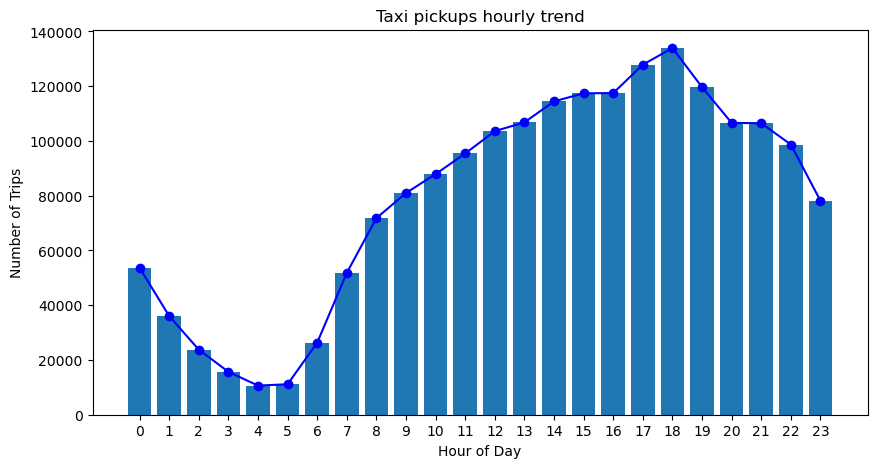

In [63]:
# Find and show the hourly trends in taxi pickups
plt.figure(figsize=(10,5))
plt.plot(total_pickups_by_hour.index, total_pickups_by_hour.values, marker='o', color='blue' )
plt.bar(total_pickups_by_hour.index, total_pickups_by_hour.values)
plt.title("Taxi pickups hourly trend")
plt.xlabel("Hour of Day")
#plt.grid()
plt.xticks(range(0,24))
plt.ylabel("Number of Trips")
plt.show()

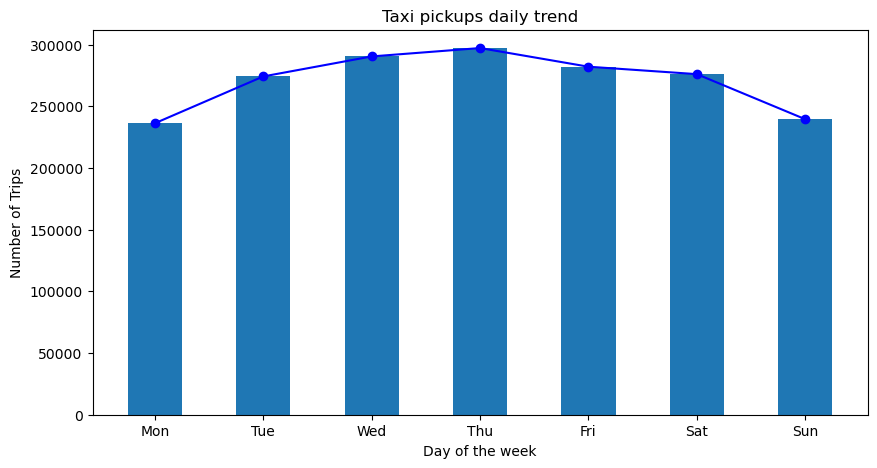

In [64]:
# Find and show the daily trends in taxi pickups (days of the week)
plt.figure(figsize=(10,5))
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.plot(days, total_pickups_by_day_of_week.values, marker='o', color='blue' )
plt.bar(days, total_pickups_by_day_of_week.values, width=0.5)
plt.title("Taxi pickups daily trend")
plt.xlabel("Day of the week")
#plt.grid()
plt.ylabel("Number of Trips")
plt.show()

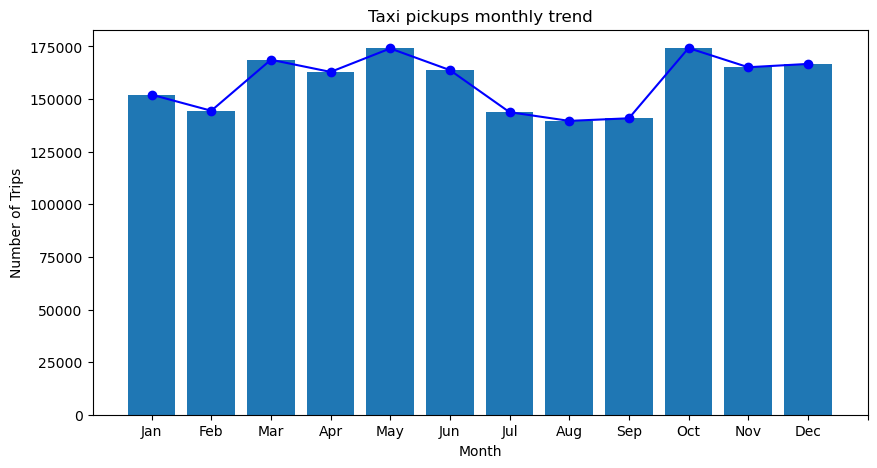

In [65]:
# Show the monthly trends in pickups

plt.figure(figsize=(10,5))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(months, total_pickups_by_month.values, marker='o', color='blue'  )
plt.bar(months, total_pickups_by_month.values)
plt.title("Taxi pickups monthly trend")
plt.xlabel("Month")
#plt.grid()
plt.xticks(range(0,13))
plt.ylabel("Number of Trips")
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [66]:
# Analyse the above parameters
df[['fare_amount','tip_amount', 'total_amount', 'trip_distance']].describe()

#There are no negative values but, there are 0 (zero's)

,fare_amount,tip_amount,total_amount,trip_distance
count,1.896232e+06,1.896232e+06,1.896232e+06,1.896232e+06
mean,1.983488e+01,3.546838e+00,2.889773e+01,3.444466e+00
std,1.813739e+01,4.052376e+00,2.271453e+01,4.534585e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.300000e+00,1.000000e+00,1.596000e+01,1.050000e+00
50%,1.350000e+01,2.850000e+00,2.100000e+01,1.800000e+00
75%,2.190000e+01,4.420000e+00,3.094000e+01,3.400000e+00
max,1.375000e+03,2.230800e+02,1.435190e+03,2.048600e+02


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?



**Response:** It is not valid to drop these records because of below reasons
* May be user booked taxi but, kept on wait and cancelled. So, there is fare involved.
* May be user travelled with same zone. 

In [67]:
df[df['trip_distance']<=0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour,day_of_week,month
77,1,2023-01-01 00:37:09,2023-01-01 00:58:16,1.0,0.0,1.0,N,36,7,1,...,0.5,0.00,0.0,1.0,32.00,2.5,0.0,0,6,1
118,2,2023-01-01 00:47:28,2023-01-01 00:47:32,1.0,0.0,5.0,N,232,232,1,...,0.0,0.00,0.0,1.0,15.00,0.0,0.0,0,6,1
127,1,2023-01-01 00:45:06,2023-01-01 00:54:06,1.0,0.0,1.0,N,48,48,2,...,0.5,0.00,0.0,1.0,13.60,2.5,0.0,0,6,1
236,1,2023-01-01 00:53:00,2023-01-01 01:07:31,1.0,0.0,1.0,N,141,79,1,...,0.5,4.45,0.0,1.0,22.25,2.5,0.0,0,6,1
280,2,2023-01-01 01:34:06,2023-01-01 01:34:14,2.0,0.0,5.0,N,265,265,1,...,0.0,10.20,0.0,1.0,61.20,0.0,0.0,1,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896208,2,2023-09-30 22:29:32,2023-09-30 22:36:11,3.0,0.0,1.0,N,264,264,1,...,0.5,2.44,0.0,1.0,14.64,2.5,0.0,22,5,9
1896234,1,2023-09-30 22:27:33,2023-09-30 22:45:51,1.0,0.0,1.0,N,237,234,1,...,0.5,0.00,0.0,1.0,23.57,2.5,0.0,22,5,9
1896313,1,2023-09-30 22:47:00,2023-09-30 22:59:51,1.0,0.0,1.0,N,68,170,1,...,0.5,0.00,0.0,1.0,21.91,2.5,0.0,22,5,9
1896356,1,2023-09-30 22:07:52,2023-09-30 22:13:26,1.0,0.0,1.0,N,238,238,1,...,0.5,0.00,0.0,1.0,11.83,2.5,0.0,22,5,9


In [68]:
# Create a df with non zero entries for the selected parameters.
#['fare_amount','tip_amount', 'total_amount', 'trip_distance']
#tip_amount is not mandatory so, zero is really a posible scenario
#trip_distance = 0  this is a valid scenario when pickup & drop are in the same zone. So, its better to retain this data as part of the dataset.
# Removing records where all of these conditions met and creating a new dataframe so, we are not losing the records 
df_non_zeros=df[(df['fare_amount']>0) & (df['tip_amount']>0) & (df['total_amount']>0) & (df['trip_distance']>0)].copy()

In [69]:
df_non_zeros.reset_index(drop=True,inplace=True)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

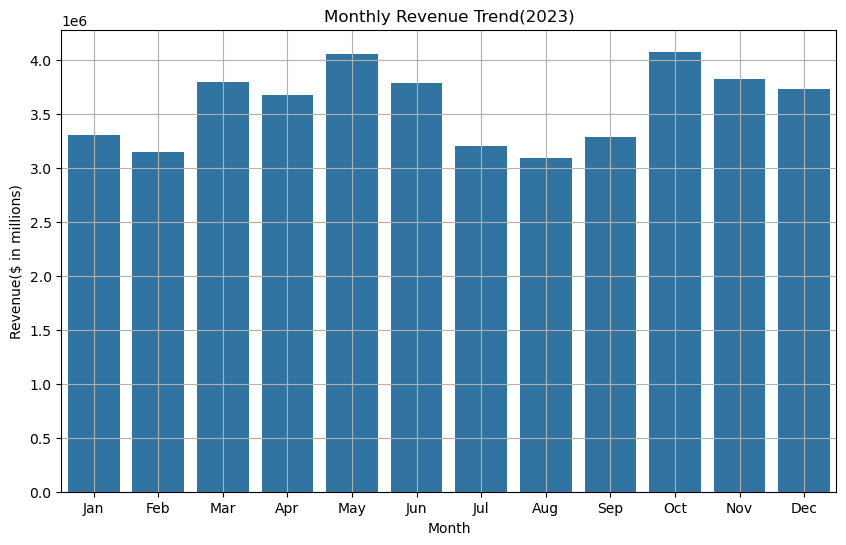

In [70]:
# Group data by month and analyse monthly revenue
monthly_revenue = (df_non_zeros.groupby('month')['total_amount'].sum().reset_index().sort_values('month'))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(10,6))
sns.barplot(data=monthly_revenue, x='month', y='total_amount')
plt.title("Monthly Revenue Trend(2023)")
plt.xticks(ticks=range(12), labels=months)
plt.xlabel("Month")
plt.ylabel("Revenue($ in millions)")
plt.grid()
plt.show()

#Aug is least in revenue and Oct is highest in revenue

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

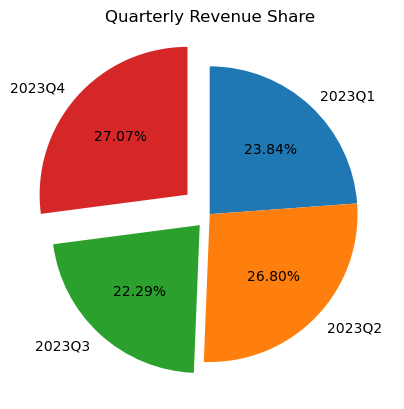

In [71]:
# Calculate proportion of each quarter
df_non_zeros['quarter'] = df_non_zeros['tpep_pickup_datetime'].dt.to_period('Q')
#Removed the only record falling under 2022Q4 because of boundary dates
df_non_zeros = df_non_zeros.drop(df_non_zeros[df_non_zeros['quarter']=='2022Q4'].index)
quarterly_revenue =(df_non_zeros.groupby('quarter')['total_amount'].sum().reset_index().sort_values('quarter'))

myexplode = [0,0,0.1,0.2]
plt.pie(
    quarterly_revenue['total_amount'],
    labels=quarterly_revenue['quarter'].astype(str),
    autopct='%1.2f%%',
    startangle=90, 
    counterclock=False,
    explode = myexplode
)
plt.title("Quarterly Revenue Share")
plt.show()


##Q4 share is high and Q3 is the least

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

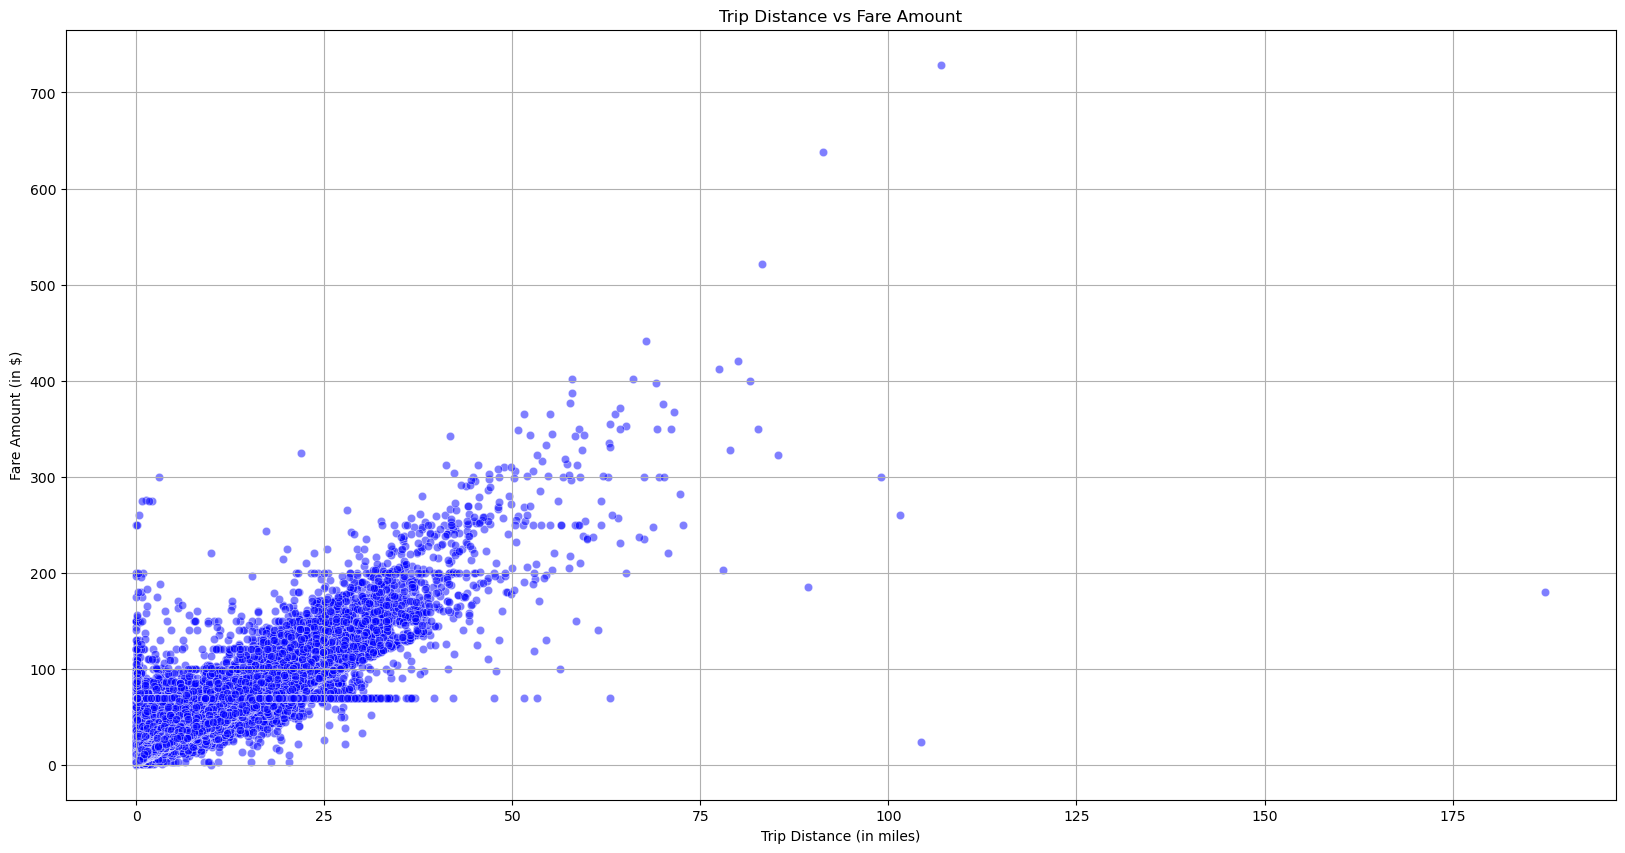

In [72]:
# Show how trip fare is affected by distance
plt.figure(figsize=(20, 10))
sns.scatterplot(data=df_non_zeros, x='trip_distance', y='fare_amount', alpha=0.5, color='b')
plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance (in miles)')
plt.ylabel('Fare Amount (in $)')
plt.grid()
plt.show()

##Majority of the trips are under 50 miles and under $200
##There are some trips where fare amount seem to be constant but, dinstance is variying

In [73]:
df_non_zeros[['trip_distance','fare_amount']].corr()

##trip_distance & fare_amount seem to have strong positive correlation

,trip_distance,fare_amount
trip_distance,1.00000,0.94948
fare_amount,0.94948,1.00000


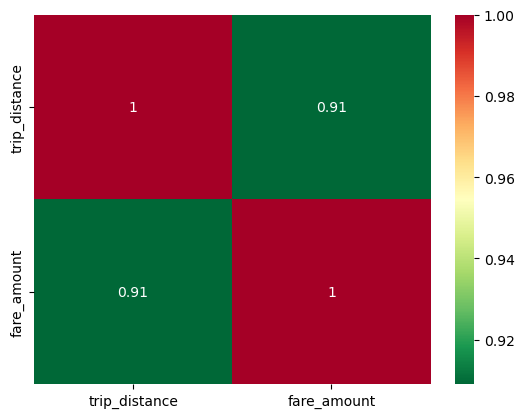

In [74]:
sns.heatmap(df[['trip_distance','fare_amount']].corr(),annot = True,cmap = 'RdYlGn_r')
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation Matrix:
                fare_amount  trip_duration
fare_amount       1.000000       0.332379
trip_duration     0.332379       1.000000


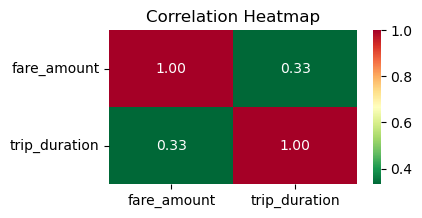

In [75]:
# Show relationship between fare and trip duration

# Derive Trip Duration 
df_non_zeros['trip_duration']=(df_non_zeros['tpep_dropoff_datetime'] - df_non_zeros['tpep_pickup_datetime']).dt.total_seconds()/60
#Found negative trip duration for the month of 5th of November. Converting them to positive values. 
df_non_zeros['trip_duration']=df_non_zeros['trip_duration'].abs()

##Function to print and plot correlation between given columns
def col_corr(df, columns_list):
    corr_matrix = df[columns_list].corr()
    print("Correlation Matrix:\n", corr_matrix)
    plt.figure(figsize=(4,2))
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn_r', fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

columns_list = ['fare_amount','trip_duration']
col_corr(df_non_zeros, columns_list)

#fare_amount & trip_duration have weak correlation

Correlation Matrix:
                  fare_amount  passenger_count
fare_amount         1.000000         0.035874
passenger_count     0.035874         1.000000


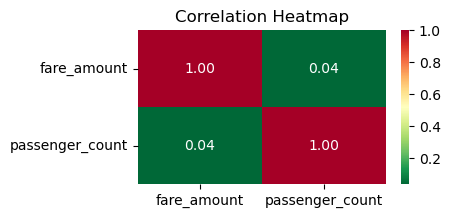

In [76]:
# Show relationship between fare and number of passengers

columns_list = ['fare_amount','passenger_count']
col_corr(df_non_zeros, columns_list)

#fare_amount & passenger_count show no correlation or negligible correlation.

Correlation Matrix:
                tip_amount  trip_distance
tip_amount       1.000000       0.797788
trip_distance    0.797788       1.000000


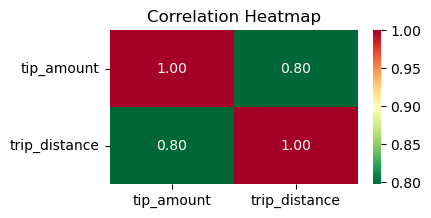

In [77]:
# Show relationship between tip and trip distance

columns_list = ['tip_amount','trip_distance']
col_corr(df_non_zeros, columns_list)

#tip_amount & trip_distance show a strong positive correlation. As the trip_distance increases , tip_amount is also increasing.

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

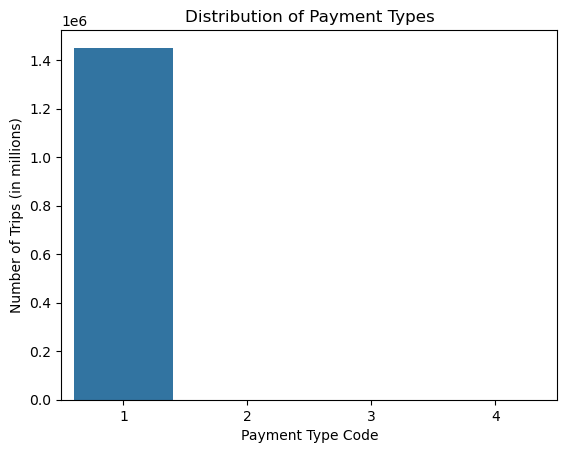

In [78]:
# Analyse the distribution of different payment types (payment_type).

trips_by_payment_type = df_non_zeros['payment_type'].value_counts()
sns.barplot(x=trips_by_payment_type.index, y=trips_by_payment_type.values)
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type Code')
plt.ylabel('Number of Trips (in millions)')
plt.show()

#Majority of the payments seem to be via credit card. 

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [79]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [80]:
os.chdir('E:\\GitRepo\\eda_nyc_taxi\\Data\\taxi_zones')

In [81]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('taxi_zones.shp')
zones.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

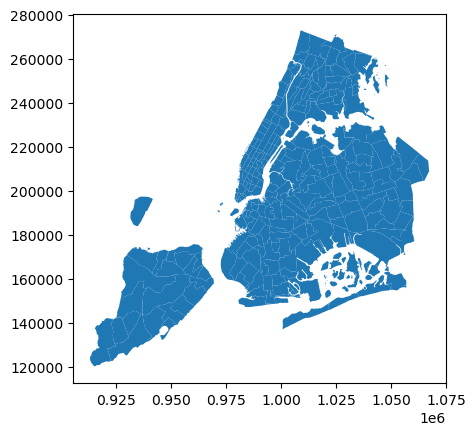

In [82]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [83]:
df_non_zeros.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1451224 entries, 0 to 1451224
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               1451224 non-null  int64         
 1   tpep_pickup_datetime   1451224 non-null  datetime64[us]
 2   tpep_dropoff_datetime  1451224 non-null  datetime64[us]
 3   passenger_count        1451224 non-null  float64       
 4   trip_distance          1451224 non-null  float64       
 5   RatecodeID             1451224 non-null  float64       
 6   store_and_fwd_flag     1451224 non-null  object        
 7   PULocationID           1451224 non-null  int64         
 8   DOLocationID           1451224 non-null  int64         
 9   payment_type           1451224 non-null  int64         
 10  fare_amount            1451224 non-null  float64       
 11  extra                  1451224 non-null  float64       
 12  mta_tax                1451224 no

In [84]:
# Merge zones and trip records using LocationID and PULocationID
#merge_df=pd.merge(df_non_zeros, zones, left_on='PULocationID', right_on='LocationID')
#zones['LocationID'] = zones['LocationID'].astype(int)
merged_df=df_non_zeros.merge(zones,how='left', left_on='PULocationID', right_on='LocationID')
#zones.info()


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [85]:
# Group data by location and calculate the number of trips
#trips_by_location=(merged_df.groupby('LocationID').size())
trips_by_location = (merged_df.groupby('LocationID').size().reset_index(name='trip_count'))
trips_by_location

,LocationID,trip_count
0,1.0,37
1,2.0,2
2,4.0,1694
3,6.0,1
4,7.0,358
...,...,...
227,259.0,1
228,260.0,111
229,261.0,7095
230,262.0,20528


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [86]:
# Merge trip counts back to the zones GeoDataFrame
zones=zones.merge(trips_by_location[['LocationID','trip_count']],how='left', on='LocationID')
zones

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",37.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",NaN
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1694.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN
...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",1.0
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",111.0
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",7095.0
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",20528.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

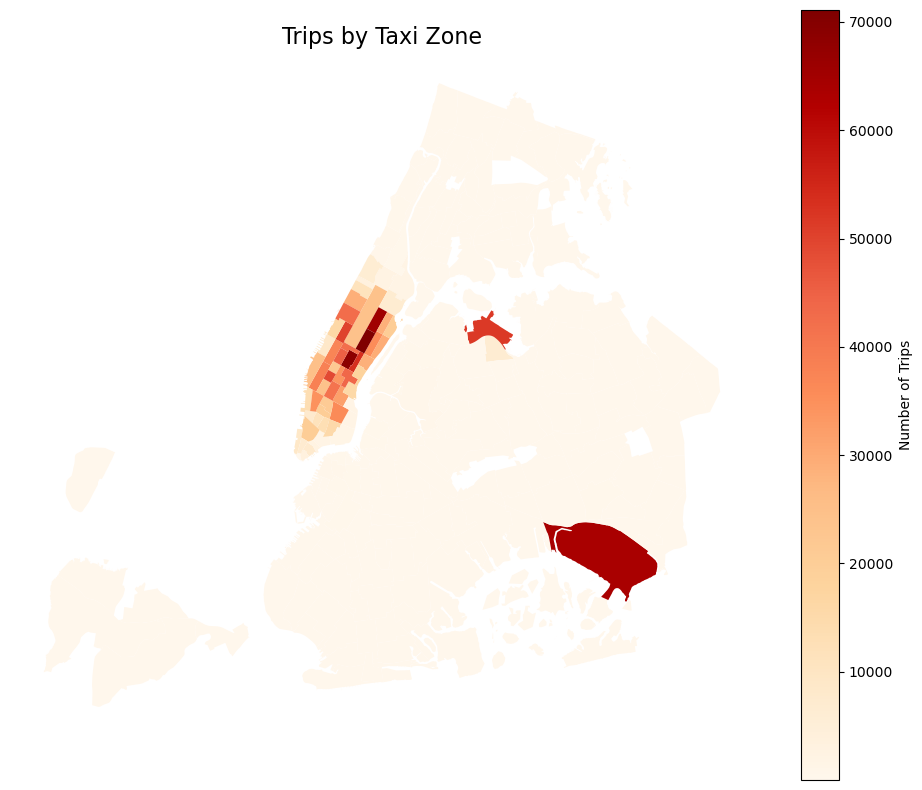

In [87]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zones.plot(column="trip_count",
                       cmap="OrRd",
                       legend=True,
                       ax=ax,
                        legend_kwds={'label': "Number of Trips",'orientation': "vertical"})
ax.set_title("Trips by Taxi Zone", fontsize=16)
ax.axis("off")
plt.show()


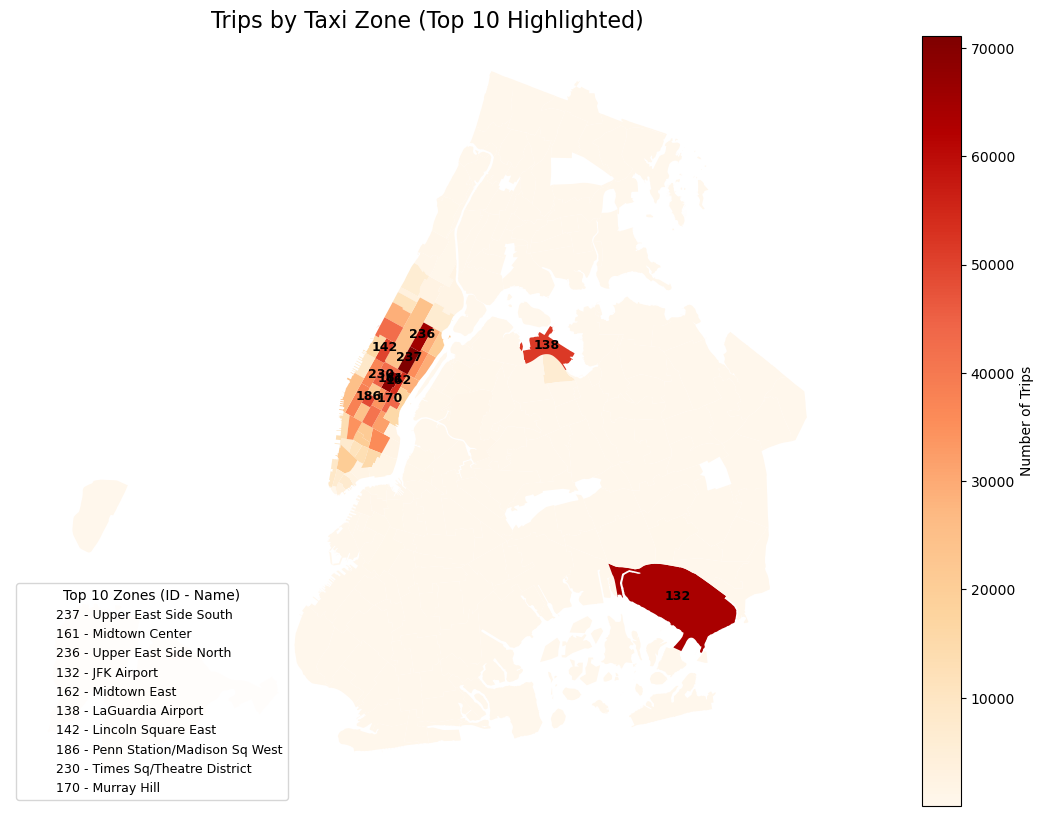

In [88]:
import matplotlib.patches as mpatches

# Sort zones by trip_count and select top 10
top10 = zones.sort_values('trip_count', ascending=False).head(10)

# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# Plot the map with legend for trip counts
zones.plot(
    column="trip_count",
    cmap="OrRd",
    legend=True,
    ax=ax,
    legend_kwds={'label': "Number of Trips", 'orientation': "vertical"}
)

# Add LocationID labels only for top 10 zones
for idx, row in top10.iterrows():
    ax.annotate(
        text=row['LocationID'],  # label with LocationID
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center',
        fontsize=9,
        color='black',
        weight='bold'
    )

# Build a custom legend for LocationID ↔ Zone name mapping
legend_elements = [
    mpatches.Patch(color='none', label=f"{row['LocationID']} - {row['zone']}")
    for _, row in top10.iterrows()
]

# Add the custom legend to the plot
ax.legend(
    handles=legend_elements,
    title="Top 10 Zones (ID - Name)",
    loc='lower left',
    fontsize=9,
    frameon=True
)

ax.set_title("Trips by Taxi Zone (Top 10 Highlighted)", fontsize=16)
ax.axis("off")
plt.show()


In [89]:
# can you try displaying the zones DF sorted by the number of trips?
zones.sort_values(by='trip_count', ascending=False)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",71101.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",68711.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",65276.0
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",63829.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",53428.0
...,...,...,...,...,...,...,...,...
203,204,0.101912,0.000641,Rossville/Woodrow,204,Staten Island,"POLYGON ((927766.539 141772.465, 927864.475 14...",NaN
205,206,0.212757,0.000944,Saint George/New Brighton,206,Staten Island,"POLYGON ((961436.305 175473.03, 961460.942 175...",NaN
213,214,0.135300,0.000812,South Beach/Dongan Hills,214,Staten Island,"POLYGON ((960669.201 156319.132, 960902.551 15...",NaN
220,221,0.166218,0.000890,Stapleton,221,Staten Island,"POLYGON ((963349.728 171627.581, 963397.759 17...",NaN


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [90]:
# Find routes which have the slowest speeds at different times of the day

##Steps to follow
#1. Calculate trip duration drop-pickup and apply transformations as per the need
#2. Route is something where pickup and drop locations are same for different trips. Combine these to form a unique route name.
#3. Calculate average trip duration for each route by hour
#4. Calculate speed as above formula provided
#5. Sort data by speed to get slow routes 

##There are some negative values. Validate data. 

merged_df['trip_duration'] = (merged_df['tpep_dropoff_datetime'] - merged_df['tpep_pickup_datetime']).dt.total_seconds() / 60
merged_df['route'] = merged_df['PULocationID'].astype(str) + "_" + merged_df['DOLocationID'].astype(str)
avg_duration = (merged_df.groupby(['route','pickup_hour'])['trip_duration'].mean().reset_index())
route_distance = (merged_df.groupby('route')['trip_distance'].mean().reset_index())
route_stats = avg_duration.merge(route_distance, on='route')
route_stats['speed'] = route_stats['trip_distance'] / (route_stats['trip_duration'] / 60)
slow_routes = route_stats.sort_values(by='speed').head(10)
slow_routes


,route,pickup_hour,trip_duration,trip_distance,speed
43284,164_33,1,-0.422222,6.082241,-864.318512
107232,90_88,1,-3.205556,3.771774,-70.598200
6246,114_120,1,-12.050000,9.880000,-49.195021
70053,238_263,1,-2.356667,1.720655,-43.807331
95259,68_226,1,-11.408333,5.525417,-29.059898
64142,234_211,1,-4.620833,1.551429,-20.144789
6140,114_106,1,-43.600000,5.630000,-7.747706
50401,198_36,1,-52.600000,1.700000,-1.939163
72198,243_264,17,1389.550000,0.180000,0.007772
38294,162_162,4,1426.366667,0.709292,0.029836


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [91]:
# Visualise the number of trips per hour and find the busiest hour

hourly_trip_counts = (merged_df['pickup_hour'].value_counts().sort_index())

# Identify busiest hour
busiest_hour = hourly_trip_counts.idxmax()
trip_count = hourly_trip_counts.max()

print(f"Busiest Hour: {busiest_hour} with Trip Count: {trip_count}")


Busiest Hour: 18 with Trip Count: 105786


In [92]:
hourly_trip_counts

pickup_hour
0      41152
1      27469
2      17711
3      11148
4       6817
5       7273
6      18793
7      39789
8      56405
9      62127
10     65278
11     70612
12     76694
13     78676
14     84977
15     87638
16     88797
17     99410
18    105786
19     94798
20     84862
21     85391
22     78836
23     60815
Name: count, dtype: int64

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [93]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers

sample_fraction =0.05

top5_busiest_hours=hourly_trip_counts.sort_values(ascending=False).head(5)
scaled_top5_busiest_hours=(top5_busiest_hours/sample_fraction).astype(int)
scaled_top5_busiest_hours

pickup_hour
18    2115720
17    1988200
19    1895960
16    1775940
15    1752760
Name: count, dtype: int32

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [94]:
# Compare traffic trends for the week days and weekends
merged_df['day_type'] = merged_df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
traffic_pattern = (merged_df.groupby(['day_type','pickup_hour']).size().reset_index(name='trip_count'))

In [95]:
traffic_pattern_by_day = (merged_df.groupby(['day_of_week','pickup_hour']).size().reset_index(name='trip_count'))

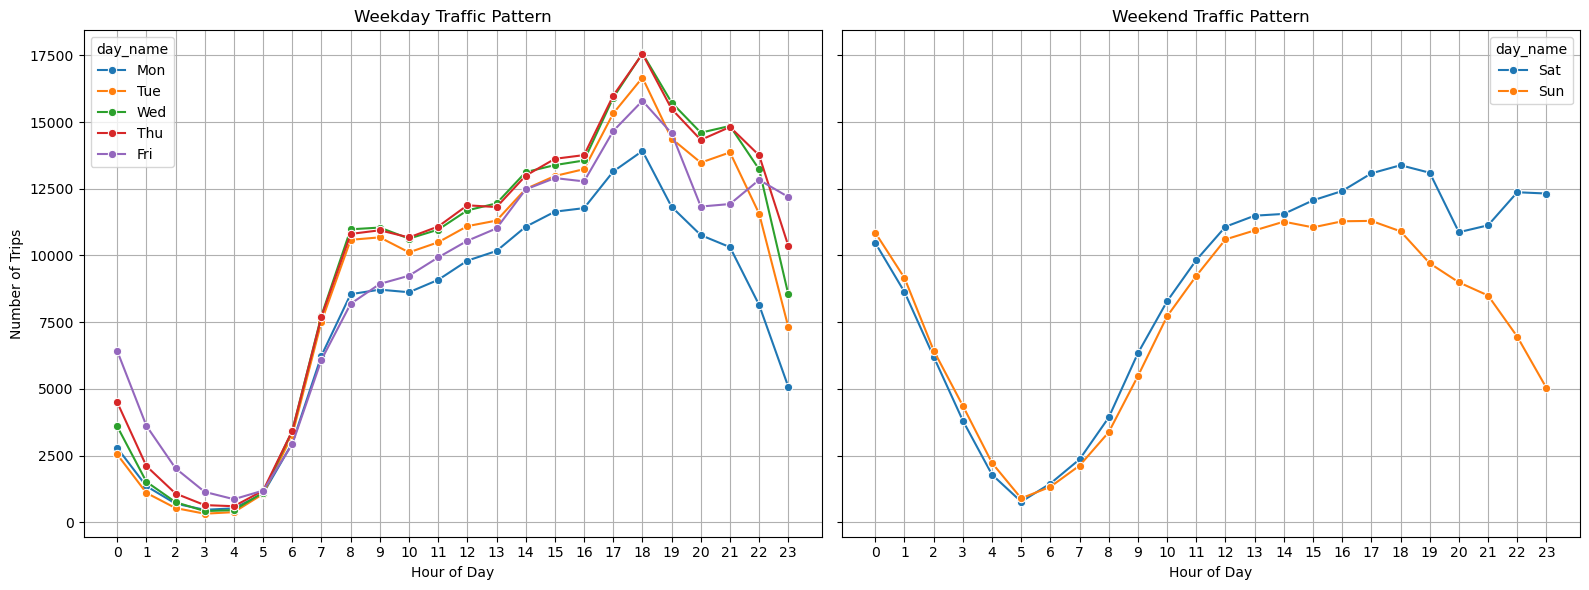

In [97]:


day_labels = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
traffic_pattern_by_day['day_name'] = traffic_pattern_by_day['day_of_week'].map(day_labels)

weekday_data = traffic_pattern_by_day[traffic_pattern_by_day['day_of_week'].isin([0,1,2,3,4])]
weekend_data = traffic_pattern_by_day[traffic_pattern_by_day['day_of_week'].isin([5,6])]


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Weekday plot
sns.lineplot(
    data=weekday_data, 
    x='pickup_hour', y='trip_count', 
    hue='day_name', marker='o', ax=axes[0]
)
axes[0].set_title("Weekday Traffic Pattern")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Trips")
axes[0].set_xticks(range(0, 24))
axes[0].grid()

# Weekend plot
sns.lineplot(
    data=weekend_data, 
    x='pickup_hour', y='trip_count', 
    hue='day_name', marker='o', ax=axes[1]
)
axes[1].set_title("Weekend Traffic Pattern")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Number of Trips")
axes[1].set_xticks(range(0, 24))
axes[1].grid()

plt.tight_layout()
plt.show()


In [98]:

#Normalized daily data to plot between weekdays and weekends. As if we plot them as is always weekdays show higher numbers. 
traffic_pattern_new = (
    merged_df.groupby(['day_type','pickup_hour'])
      .size()
      .reset_index(name='trip_count')
)

# Normalize by number of days in each group
merged_df['pickup_date'] = merged_df['tpep_pickup_datetime'].dt.date
day_counts = merged_df.groupby('day_type')['pickup_date'].nunique()

traffic_pattern_new['trip_count_norm'] = traffic_pattern_new.apply(
    lambda row: row['trip_count'] / day_counts[row['day_type']], axis=1
)
#Log value calculation
traffic_pattern_new['trip_count_log'] = np.log1p(traffic_pattern_new['trip_count_norm'])


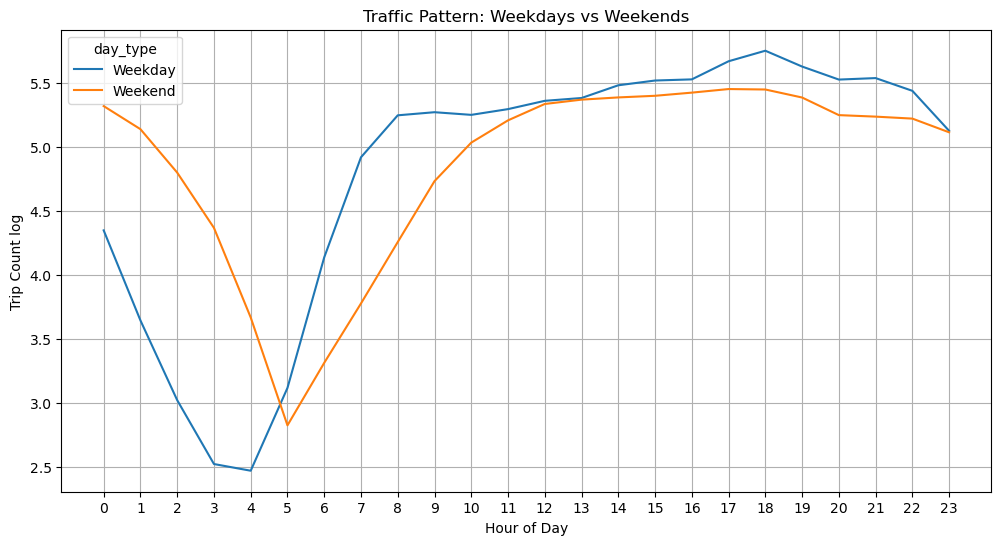

In [99]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=traffic_pattern_new, x='pickup_hour', y='trip_count_log', hue='day_type')
plt.title("Traffic Pattern: Weekdays vs Weekends")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count log")
plt.xticks(range(0, 24))
plt.grid()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [100]:
# Find top 10 pickup and dropoff zones
# Pickup hour already caculated
# Dropoff hour
merged_df['dropoff_hour'] = merged_df['tpep_dropoff_datetime'].dt.hour
# Hourly pickups by zone
pickup_counts = (merged_df.groupby(['PULocationID','pickup_hour']).size().reset_index(name='pickup_count'))
# Hourly dropoffs by zone
dropoff_counts = (merged_df.groupby(['DOLocationID','dropoff_hour']).size().reset_index(name='dropoff_count'))

In [101]:
top_pickup_zones=pickup_counts.groupby('PULocationID')['pickup_count'].sum().sort_values(ascending=False).head(10).index
top_pickup_zones

Index([237, 161, 236, 132, 162, 138, 142, 186, 230, 170], dtype='int64', name='PULocationID')

In [102]:
top_dropoff_zones=dropoff_counts.groupby('DOLocationID')['dropoff_count'].sum().sort_values(ascending=False).head(10).index
top_dropoff_zones

Index([236, 237, 161, 170, 239, 142, 162, 141, 230, 68], dtype='int64', name='DOLocationID')

In [103]:
pickup_top10=pickup_counts[pickup_counts['PULocationID'].isin(top_pickup_zones)]
dropoff_top10=dropoff_counts[dropoff_counts['DOLocationID'].isin(top_dropoff_zones)]

In [104]:
pickup_top10

,PULocationID,pickup_hour,pickup_count
1470,132,0,2689
1471,132,1,1157
1472,132,2,369
1473,132,3,214
1474,132,4,173
...,...,...,...
2884,237,19,4580
2885,237,20,3868
2886,237,21,3933
2887,237,22,2965


In [105]:
# Pivot pickups
pickup_pivot = pickup_top10.pivot(index='pickup_hour', columns='PULocationID', values='pickup_count').fillna(0)

# Pivot dropoffs
dropoff_pivot = dropoff_top10.pivot(index='dropoff_hour', columns='DOLocationID', values='dropoff_count').fillna(0)


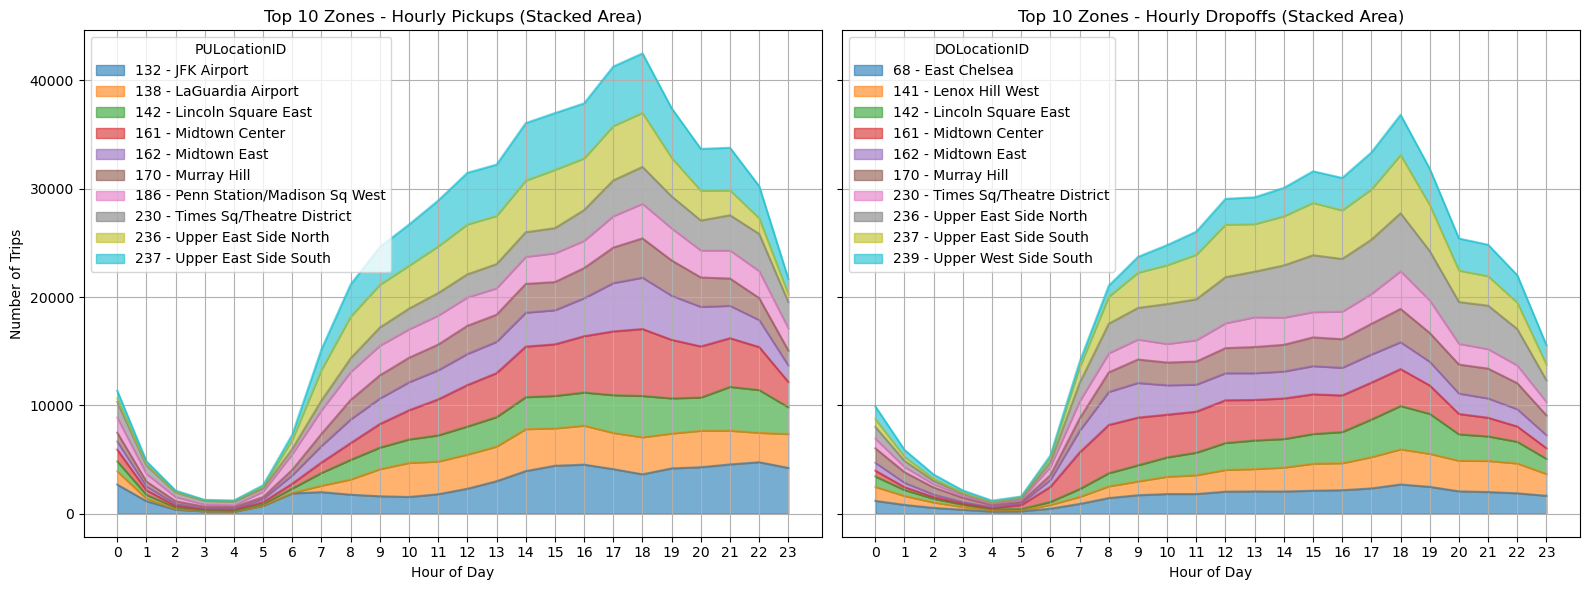

In [106]:
# Build a mapping: "code - name"
zone_map = {row['LocationID']: f"{row['LocationID']} - {row['zone']}" 
            for _, row in zones.iterrows()}

# Apply mapping to pivot tables
pickup_pivot_named = pickup_pivot.rename(columns=zone_map)
dropoff_pivot_named = dropoff_pivot.rename(columns=zone_map)

# Plot with updated legend
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Pickups stacked area
pickup_pivot_named.plot.area(ax=axes[0], alpha=0.6)
axes[0].set_title("Top 10 Zones - Hourly Pickups (Stacked Area)")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Trips")
axes[0].set_xticks(range(0, 24))
axes[0].grid()

# Dropoffs stacked area
dropoff_pivot_named.plot.area(ax=axes[1], alpha=0.6)
axes[1].set_title("Top 10 Zones - Hourly Dropoffs (Stacked Area)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Number of Trips")
axes[1].set_xticks(range(0, 24))
axes[1].grid()

plt.tight_layout()
plt.show()


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [107]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

pickup_totals = merged_df.groupby('PULocationID').size().reset_index(name='pickup_count')
pickup_totals.rename(columns={'PULocationID':'zone_id'}, inplace=True)
dropoff_totals = merged_df.groupby('DOLocationID').size().reset_index(name='dropoff_count')
dropoff_totals.rename(columns={'DOLocationID':'zone_id'}, inplace=True)
zone_counts = pd.merge(pickup_totals, dropoff_totals, on='zone_id', how='outer').fillna(0)

zone_counts = zone_counts[zone_counts['zone_id'] != 0]

zone_counts['pickup_drop_ratio'] = round(zone_counts['pickup_count'] / zone_counts['dropoff_count'].replace(0, np.nan),2)

zone_map = dict(zip(zones['LocationID'], zones['zone']))
zone_counts['zone_name'] = zone_counts['zone_id'].map(zone_map)

top10_high = zone_counts.nlargest(10, 'pickup_drop_ratio')[['zone_id','zone_name','pickup_count','dropoff_count','pickup_drop_ratio']]
top10_low = zone_counts.nsmallest(10, 'pickup_drop_ratio')[['zone_id','zone_name','pickup_count','dropoff_count','pickup_drop_ratio']]


In [108]:
top10_high

,zone_id,zone_name,pickup_count,dropoff_count,pickup_drop_ratio
69,70,East Elmhurst,6448.0,483.0,13.35
126,132,JFK Airport,63829.0,15025.0,4.25
132,138,LaGuardia Airport,51869.0,20123.0,2.58
201,207,Saint Michaels Cemetery/Woodside,12.0,7.0,1.71
180,186,Penn Station/Madison Sq West,49143.0,30055.0,1.64
108,114,Greenwich Village South,20359.0,14691.0,1.39
42,43,Central Park,24311.0,17571.0,1.38
243,249,West Village,34689.0,25996.0,1.33
156,162,Midtown East,53428.0,42297.0,1.26
98,100,Garment District,21723.0,17813.0,1.22


In [109]:
top10_low

,zone_id,zone_name,pickup_count,dropoff_count,pickup_drop_ratio
2,3,Allerton/Pelham Gardens,0.0,54.0,0.0
4,5,Arden Heights,0.0,5.0,0.0
26,27,Breezy Point/Fort Tilden/Riis Beach,0.0,21.0,0.0
29,30,Broad Channel,0.0,7.0,0.0
31,32,Bronxdale,0.0,38.0,0.0
43,44,Charleston/Tottenville,0.0,3.0,0.0
57,58,Country Club,0.0,21.0,0.0
83,84,Eltingville/Annadale/Prince's Bay,0.0,6.0,0.0
85,86,Far Rockaway,0.0,90.0,0.0
93,94,Fordham South,0.0,39.0,0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [110]:
merged_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour',
       'day_of_week', 'month', 'quarter', 'trip_duration', 'OBJECTID',
       'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry',
       'route', 'day_type', 'pickup_date', 'dropoff_hour'],
      dtype='object')

In [111]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

#night_trips = merged_df[(merged_df['pickup_hour'] >= 23) | (merged_df['pickup_hour'] <= 5)]
night_trips = merged_df[(merged_df['pickup_hour'] >= 23) | (merged_df['pickup_hour'] <= 5) |
                 (merged_df['dropoff_hour']   >= 23) | (merged_df['dropoff_hour']   <= 5)]

pickups = night_trips.groupby('PULocationID').size().reset_index(name='pickup_count')
dropoffs = night_trips.groupby('DOLocationID').size().reset_index(name='dropoff_count')

top_pickups = pickups.sort_values('pickup_count', ascending=False).head(10)
top_dropoffs = dropoffs.sort_values('dropoff_count', ascending=False).head(10)


In [112]:
top_pickups

,PULocationID,pickup_count
51,79,13974
85,132,12435
178,249,11573
29,48,8975
99,148,8627
71,114,7945
163,230,6867
127,186,6069
91,138,5694
113,164,5401


In [113]:
top_dropoffs

,DOLocationID,dropoff_count
77,79,7413
46,48,5723
163,170,5505
101,107,5302
134,141,5137
66,68,5013
254,263,4869
240,249,4552
230,239,4402
227,236,4352


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [114]:
# Filter for night hours (11 PM to 5 AM)

#Considering only the pickup hour to calculate the night. 
#There may be trips that may start during day time hours and end during night time hours. 
merged_df['time_period'] = merged_df['pickup_hour'].apply(lambda h: 'Night' if (h >= 23 or h < 5) else 'Day')

# Revenue by period
revenue_share = (merged_df.groupby('time_period')['total_amount'].sum().reset_index())

# Compute percentage share
total_revenue = revenue_share['total_amount'].sum()
revenue_share['share_percent'] = round((revenue_share['total_amount'] / total_revenue) * 100, 2)

revenue_share


,time_period,total_amount,share_percent
0,Day,38150264.47,88.65
1,Night,4884035.27,11.35


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [115]:
# Analyse the fare per mile per passenger for different passenger counts

merged_df['fare_per_mile'] = merged_df['fare_amount'] / merged_df['trip_distance']
merged_df['fare_per_mile_per_passenger'] = merged_df['fare_per_mile'] / merged_df['passenger_count']
avg_fare_per_passenger = merged_df.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().round(2).reset_index()

In [116]:
avg_fare_per_passenger

,passenger_count,fare_per_mile_per_passenger
0,1.0,9.26
1,2.0,5.00
2,3.0,3.33
3,4.0,3.91
4,5.0,1.59
5,6.0,1.28


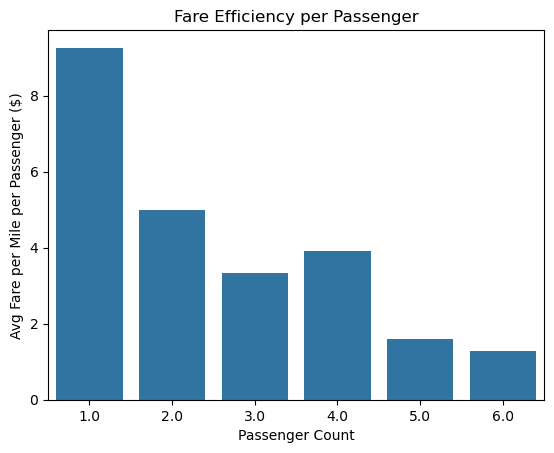

In [117]:
sns.barplot(
    data=avg_fare_per_passenger,
    x='passenger_count', y='fare_per_mile_per_passenger'
)

plt.xlabel("Passenger Count")
plt.ylabel("Avg Fare per Mile per Passenger ($)")
plt.title("Fare Efficiency per Passenger")
plt.show()


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [118]:
# Compare the average fare per mile for different days and for different times of the day

day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
merged_df['day_label'] = merged_df['day_of_week'].map(day_map)

avg_fare_day_hour = (merged_df.groupby(['day_label','day_of_week','pickup_hour'])['fare_per_mile'].mean().round(2).reset_index())
avg_fare_day_hour


,day_label,day_of_week,pickup_hour,fare_per_mile
0,Fri,4,0,6.85
1,Fri,4,1,7.24
2,Fri,4,2,9.41
3,Fri,4,3,9.90
4,Fri,4,4,9.39
...,...,...,...,...
163,Wed,2,19,9.06
164,Wed,2,20,8.19
165,Wed,2,21,6.94
166,Wed,2,22,7.71


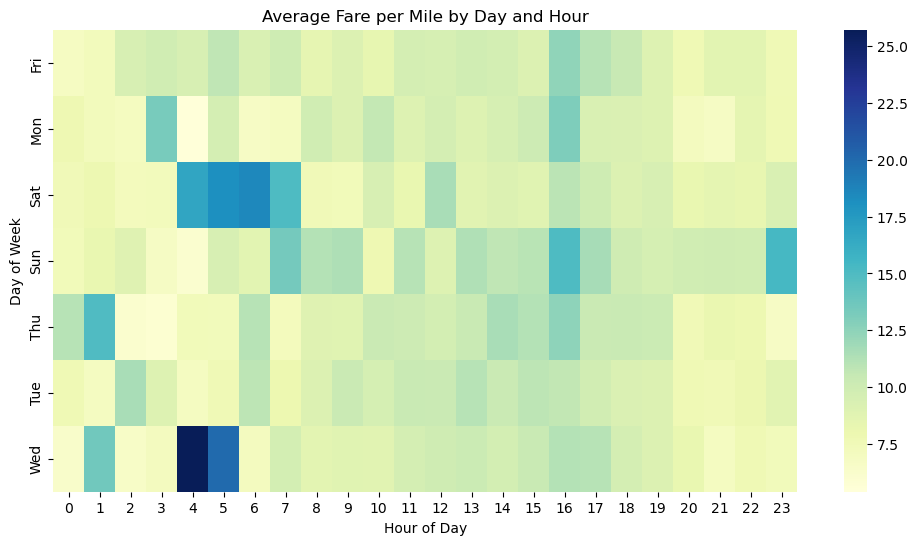

In [119]:

pivot = avg_fare_day_hour.pivot(index='day_label', columns='pickup_hour', values='fare_per_mile')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu", annot=False)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Average Fare per Mile by Day and Hour")
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [195]:
# Compare fare per mile for different vendors

#vendor_map = {1: 'Creative Mobile Technologies, LLC', 2: 'VeriFone Inc.'}
#merged_df['vendor_name'] = merged_df['VendorID'].map(vendor_map)

avg_fare_vendor_hour = (merged_df.groupby(['VendorID','vendor_name','pickup_hour'])['fare_per_mile'].mean().round(2).reset_index())
avg_fare_vendor_hour

,VendorID,vendor_name,pickup_hour,fare_per_mile
0,1,"Creative Mobile Technologies, LLC",0,6.72
1,1,"Creative Mobile Technologies, LLC",1,6.76
2,1,"Creative Mobile Technologies, LLC",2,6.84
3,1,"Creative Mobile Technologies, LLC",3,6.38
4,1,"Creative Mobile Technologies, LLC",4,6.98
5,1,"Creative Mobile Technologies, LLC",5,7.07
6,1,"Creative Mobile Technologies, LLC",6,6.38
7,1,"Creative Mobile Technologies, LLC",7,7.01
8,1,"Creative Mobile Technologies, LLC",8,7.93
9,1,"Creative Mobile Technologies, LLC",9,8.25


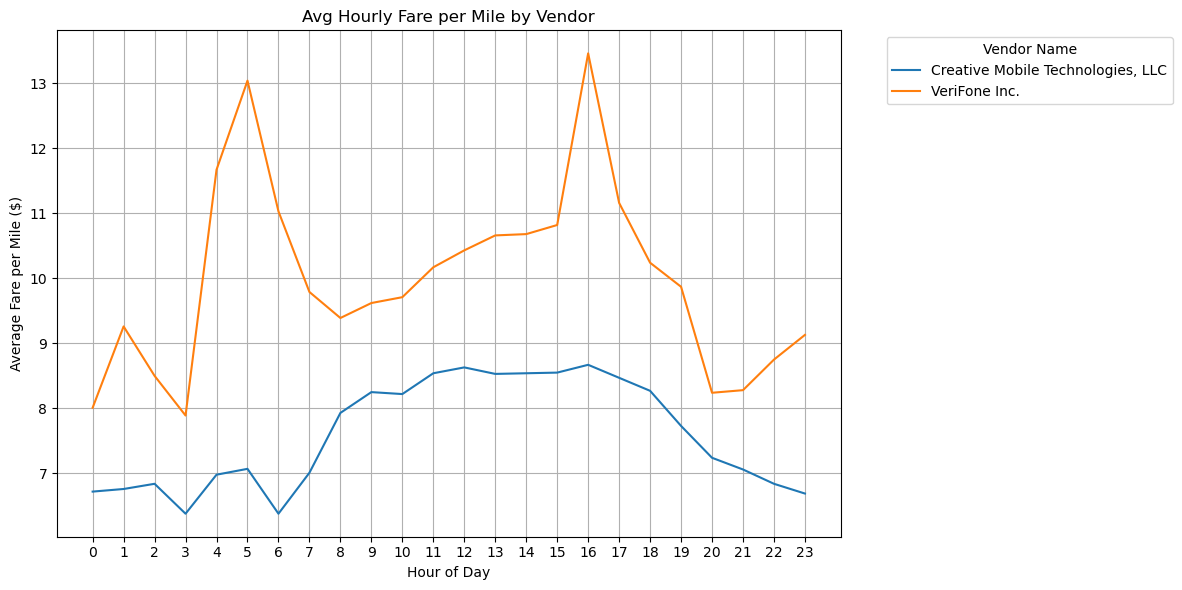

In [202]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=avg_fare_vendor_hour,
    x='pickup_hour', y='fare_per_mile', hue='vendor_name'
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Fare per Mile ($)")
plt.title("Avg Hourly Fare per Mile by Vendor")
plt.legend(title="Vendor Name", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.grid()
plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [133]:
# Defining distance tiers
vendor_map = {1: 'Creative Mobile Technologies, LLC', 2: 'VeriFone Inc.'}
merged_df['vendor_name'] = merged_df['VendorID'].map(vendor_map)

#Categorizing trips by distance
#Short Trips(<=2 miles)
#Medium Trips(2-5 miles)
#Long Trips(>5 miles)

merged_df['distance_tier'] = pd.cut(merged_df['trip_distance'],bins=[0, 2, 5, float('inf')],labels=['Short Trips', 'Medium Trips', 'Long Trips'])
avg_fare_vendor_tier = merged_df.groupby(['VendorID','vendor_name','distance_tier'], observed=True)['fare_per_mile'].mean().round(2).reset_index()
avg_fare_vendor_tier



,VendorID,vendor_name,distance_tier,fare_per_mile
0,1,"Creative Mobile Technologies, LLC",Short Trips,9.51
1,1,"Creative Mobile Technologies, LLC",Medium Trips,6.36
2,1,"Creative Mobile Technologies, LLC",Long Trips,4.47
3,2,VeriFone Inc.,Short Trips,13.71
4,2,VeriFone Inc.,Medium Trips,6.53
5,2,VeriFone Inc.,Long Trips,4.49


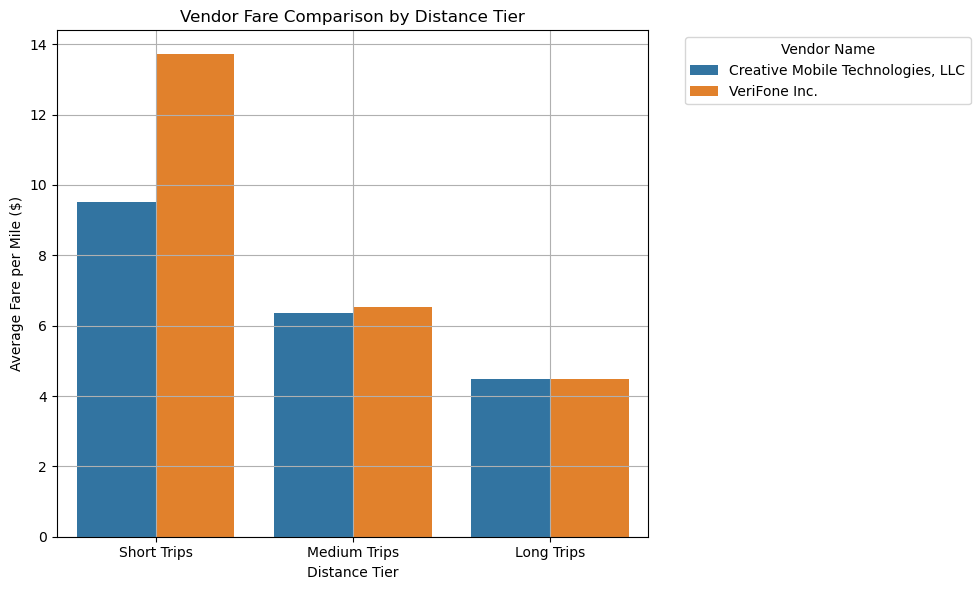

In [205]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=avg_fare_vendor_tier,
    x='distance_tier', y='fare_per_mile', hue='vendor_name'
)
plt.xlabel("Distance Tier")
plt.ylabel("Average Fare per Mile ($)")
plt.title("Vendor Fare Comparison by Distance Tier")
plt.legend(title="Vendor Name", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [140]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

merged_df['tip_percent'] = (merged_df['tip_amount'] / merged_df['fare_amount']) * 100

avg_tip_distance=merged_df.groupby(['distance_tier'], observed=True)['tip_percent'].mean().round(2).reset_index()
avg_tip_passenger=merged_df.groupby('passenger_count')['tip_percent'].mean().round(2).reset_index()
avg_tip_hour=merged_df.groupby('pickup_hour')['tip_percent'].mean().round(2).reset_index()

avg_tip_combo=merged_df.groupby(['distance_tier','passenger_count','pickup_hour'], observed=True)['tip_percent'].mean().round(2).reset_index()

In [141]:
avg_tip_distance

,distance_tier,tip_percent
0,Short Trips,28.77
1,Medium Trips,23.06
2,Long Trips,23.37


In [142]:
avg_tip_passenger

,passenger_count,tip_percent
0,1.0,26.34
1,2.0,25.82
2,3.0,25.81
3,4.0,25.89
4,5.0,26.05
5,6.0,26.16


In [143]:
avg_tip_hour

,pickup_hour,tip_percent
0,0,25.71
1,1,26.02
2,2,26.38
3,3,27.29
4,4,26.48
5,5,25.59
6,6,24.95
7,7,24.78
8,8,24.81
9,9,25.16


In [138]:
avg_tip_combo

,distance_tier,passenger_count,pickup_hour,tip_percent
0,Short Trips,1.0,0,30.03
1,Short Trips,1.0,1,30.48
2,Short Trips,1.0,2,30.93
3,Short Trips,1.0,3,33.31
4,Short Trips,1.0,4,32.62
...,...,...,...,...
427,Long Trips,6.0,19,23.13
428,Long Trips,6.0,20,21.40
429,Long Trips,6.0,21,21.29
430,Long Trips,6.0,22,20.31


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [125]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [181]:
# See how passenger count varies across hours and days
passenger_by_hour = merged_df.groupby('pickup_hour')['passenger_count'].mean().round(2).reset_index()
passenger_by_day = merged_df.groupby(['day_label','day_of_week'])['passenger_count'].mean().round(2).reset_index()
passenger_trends = merged_df.groupby(['day_label','pickup_hour'])['passenger_count'].mean().round(2).reset_index()

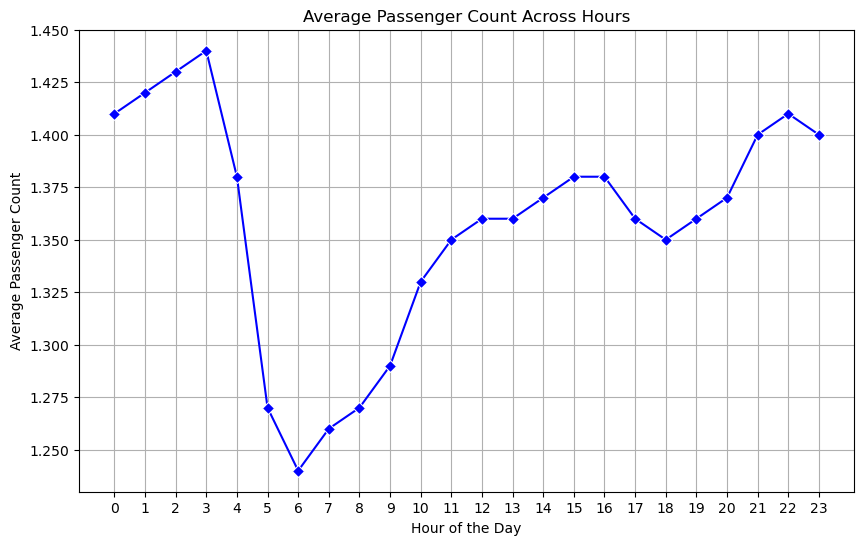

In [170]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=passenger_by_hour['pickup_hour'], y=passenger_by_hour['passenger_count'], marker='D', color='blue')
plt.xlabel("Hour of the Day")
plt.ylabel("Average Passenger Count")
plt.title("Average Passenger Count Across Hours")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


In [179]:
merged_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour',
       'day_of_week', 'month', 'quarter', 'trip_duration', 'OBJECTID',
       'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry',
       'route', 'day_type', 'pickup_date', 'dropoff_hour', 'time_period',
       'fare_per_mile', 'fare_per_mile_per_passenger', 'day_label',
       'vendor_name', 'distance_tier', 'tip_percent'],
      dtype='object')

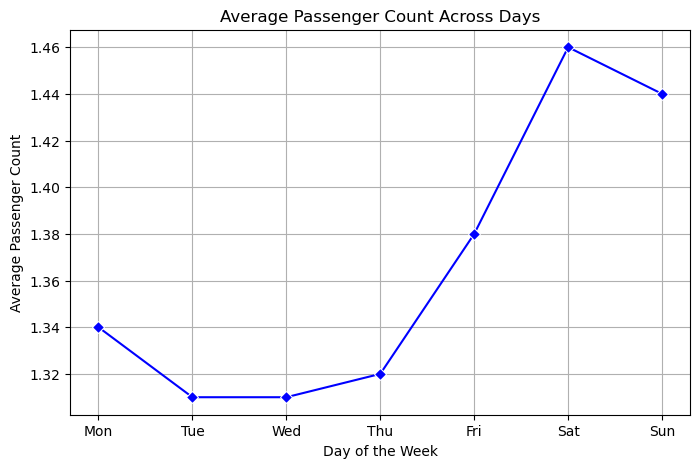

In [185]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=passenger_by_day['day_of_week'], y=passenger_by_day['passenger_count'], marker='D', color='blue')
plt.xlabel("Day of the Week")
plt.ylabel("Average Passenger Count")
plt.title("Average Passenger Count Across Days")
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(True)
plt.show()


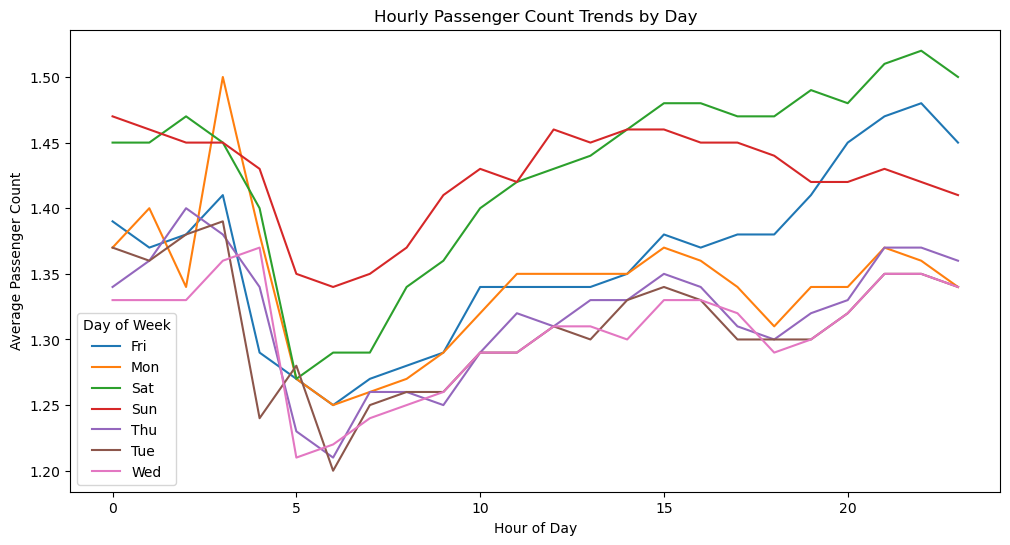

In [207]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=passenger_trends,
    x='pickup_hour', y='passenger_count', hue='day_label'
)
plt.xlabel("Hour of Day")
plt.ylabel("Average Passenger Count")
plt.title("Hourly Passenger Count Trends by Day")
plt.legend(title="Day of Week")
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [210]:
# How does passenger count vary across zones

passenger_by_zone = merged_df.groupby(['PULocationID','zone'])['passenger_count'].mean().round(2).reset_index().rename(columns={'PULocationID':'zone_id','passenger_count':'avg_passenger_count'})


In [211]:
passenger_by_zone

,zone_id,zone,avg_passenger_count
0,1,Newark Airport,1.32
1,2,Jamaica Bay,1.00
2,4,Alphabet City,1.37
3,6,Arrochar/Fort Wadsworth,3.00
4,7,Astoria,1.24
...,...,...,...
227,259,Woodlawn/Wakefield,1.00
228,260,Woodside,1.36
229,261,World Trade Center,1.48
230,262,Yorkville East,1.31


In [215]:
zones.columns

Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry', 'trip_count'],
      dtype='object')

In [220]:
zones.shape

(263, 8)

In [217]:
merged_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour',
       'day_of_week', 'month', 'quarter', 'trip_duration', 'OBJECTID',
       'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry',
       'route', 'day_type', 'pickup_date', 'dropoff_hour', 'time_period',
       'fare_per_mile', 'fare_per_mile_per_passenger', 'day_label',
       'vendor_name', 'distance_tier', 'tip_percent'],
      dtype='object')

In [223]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
zones_with_trips = zones.merge(passenger_by_zone, left_on='LocationID',right_on='zone_id', how='left')

In [230]:
zones_with_trips

,OBJECTID,Shape_Leng,Shape_Area,zone_x,LocationID,borough,geometry,trip_count,zone_id,zone_y,avg_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",37.0,1.0,Newark Airport,1.32
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,2.0,Jamaica Bay,1.00
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",NaN,NaN,NaN,NaN
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1694.0,4.0,Alphabet City,1.37
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",1.0,259.0,Woodlawn/Wakefield,1.00
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",111.0,260.0,Woodside,1.36
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",7095.0,261.0,World Trade Center,1.48
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",20528.0,262.0,Yorkville East,1.31


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [233]:
merged_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour',
       'day_of_week', 'month', 'quarter', 'trip_duration', 'OBJECTID',
       'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry',
       'route', 'day_type', 'pickup_date', 'dropoff_hour', 'time_period',
       'fare_per_mile', 'fare_per_mile_per_passenger', 'day_label',
       'vendor_name', 'distance_tier', 'tip_percent'],
      dtype='object')

In [247]:
# How often is each surcharge applied?

surcharge_cols = ['extra','mta_tax','improvement_surcharge','congestion_surcharge','Airport_fee']
prevalence = {}
for col in surcharge_cols:
    prevalence[col] = (merged_df[col] > 0).mean() * 100
prevalence
#print(f"Surcharge {prevalence.key} applied {prevalence.key})

##mta_tax & improvemet_surchages are applied almost in every ride
##Airport_fee applied is very less
##If we exlcude mta_tax & improvemet_surchages which are applied for all the trips. congestion_surcharge is the most applied surcharge and then comes extra charges. 




{'extra': 62.174850164065006,
 'mta_tax': 99.4170558703025,
 'improvement_surcharge': 99.99841516371359,
 'congestion_surcharge': 95.07632709367209,
 'Airport_fee': 8.00397449378262}

In [248]:
congestion_surcharge_by_time = (
    merged_df.groupby(['day_label','pickup_hour'])['congestion_surcharge']
      .apply(lambda x: (x > 0).mean() * 100)
      .reset_index()
)
congestion_surcharge_by_time

,day_label,pickup_hour,congestion_surcharge
0,Fri,0,94.812276
1,Fri,1,95.629322
2,Fri,2,96.584158
3,Fri,3,96.214789
4,Fri,4,93.387471
...,...,...,...
163,Wed,19,95.810553
164,Wed,20,95.856164
165,Wed,21,95.960412
166,Wed,22,95.803403


In [249]:
congestion_surcharge_by_zone = (
    merged_df.groupby(['PULocationID','zone'])['congestion_surcharge']
      .apply(lambda x: (x > 0).mean() * 100)
      .reset_index()
)
congestion_surcharge_by_zone

,PULocationID,zone,congestion_surcharge
0,1,Newark Airport,8.108108
1,2,Jamaica Bay,100.000000
2,4,Alphabet City,99.822904
3,6,Arrochar/Fort Wadsworth,0.000000
4,7,Astoria,58.379888
...,...,...,...
227,259,Woodlawn/Wakefield,100.000000
228,260,Woodside,49.549550
229,261,World Trade Center,98.773784
230,262,Yorkville East,99.805144


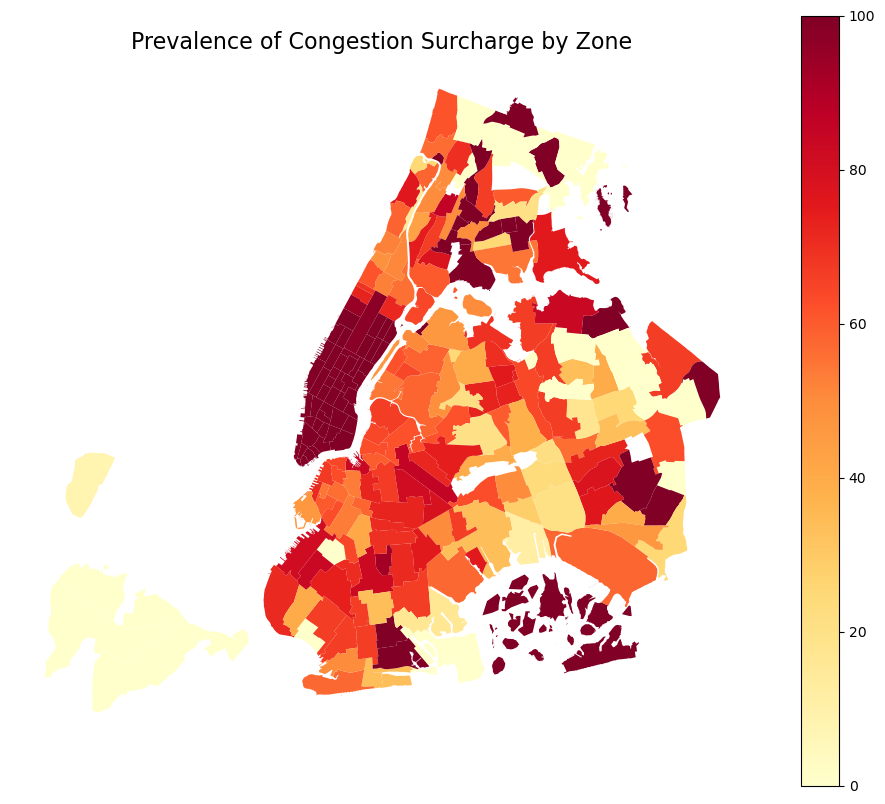

In [263]:
zones_congestion = zones.merge(congestion_surcharge_by_zone, left_on="LocationID", right_on="PULocationID", how="left")

fig, ax = plt.subplots(1, 1, figsize=(12,10))
zones_congestion.plot(column="congestion_surcharge", cmap="YlOrRd", legend=True, ax=ax)
ax.set_title("Prevalence of Congestion Surcharge by Zone", fontsize=16)
ax.axis("off")
plt.show()

In [250]:
extra_by_time = (
    merged_df.groupby(['day_label','pickup_hour'])['extra']
      .apply(lambda x: (x > 0).mean() * 100)
      .reset_index()
)
extra_by_time


,day_label,pickup_hour,extra
0,Fri,0,95.357532
1,Fri,1,95.739972
2,Fri,2,96.287129
3,Fri,3,93.573944
4,Fri,4,77.726218
...,...,...,...
163,Wed,19,98.474253
164,Wed,20,96.520548
165,Wed,21,96.323975
166,Wed,22,95.614367


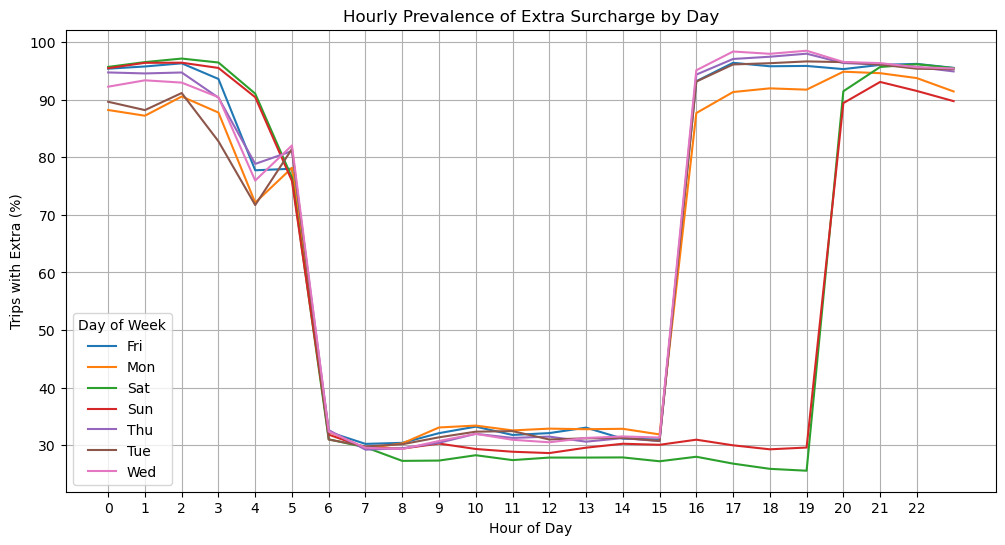

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=extra_by_time, x='pickup_hour', y='extra', hue='day_label')
plt.legend(title="Day of Week")
plt.title("Hourly Prevalence of Extra Surcharge by Day")
plt.xlabel("Hour of Day")
plt.ylabel("Trips with Extra (%)")
plt.xticks(range(0,23))
plt.grid(True)
plt.show()


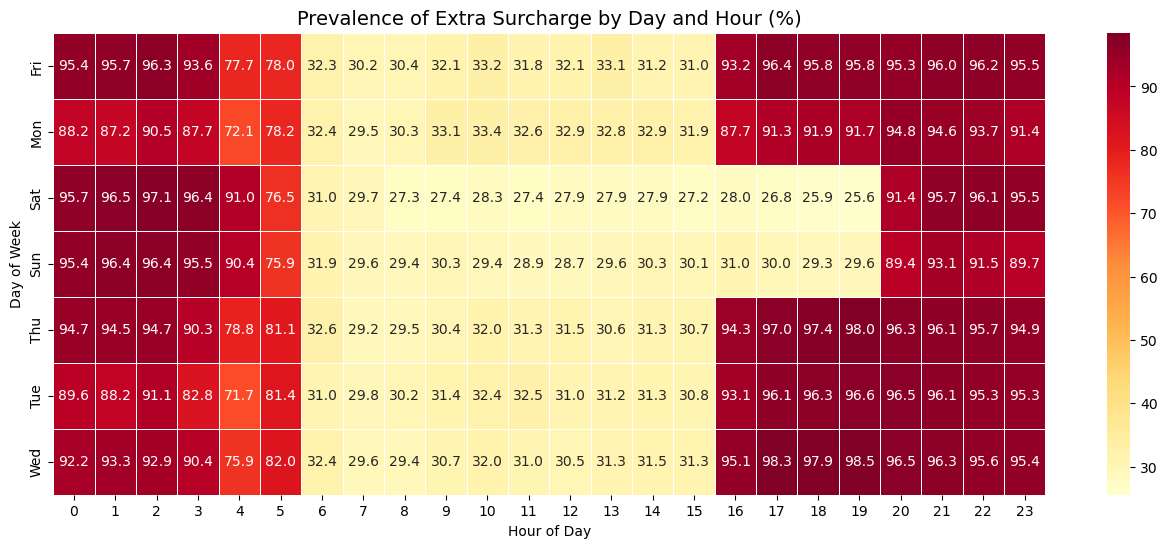

In [ ]:
pivot = extra_by_time.pivot(index='day_label', columns='pickup_hour', values='extra')

plt.figure(figsize=(16,6))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=.5)
plt.title("Prevalence of Extra Surcharge by Day and Hour (%)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()


In [251]:
extra_by_zone = (
    merged_df.groupby(['PULocationID','zone'])['extra']
      .apply(lambda x: (x > 0).mean() * 100)
      .reset_index()
)
extra_by_zone

,PULocationID,zone,extra
0,1,Newark Airport,10.810811
1,2,Jamaica Bay,0.000000
2,4,Alphabet City,71.723731
3,6,Arrochar/Fort Wadsworth,100.000000
4,7,Astoria,36.033520
...,...,...,...
227,259,Woodlawn/Wakefield,0.000000
228,260,Woodside,37.837838
229,261,World Trade Center,56.730092
230,262,Yorkville East,46.336711


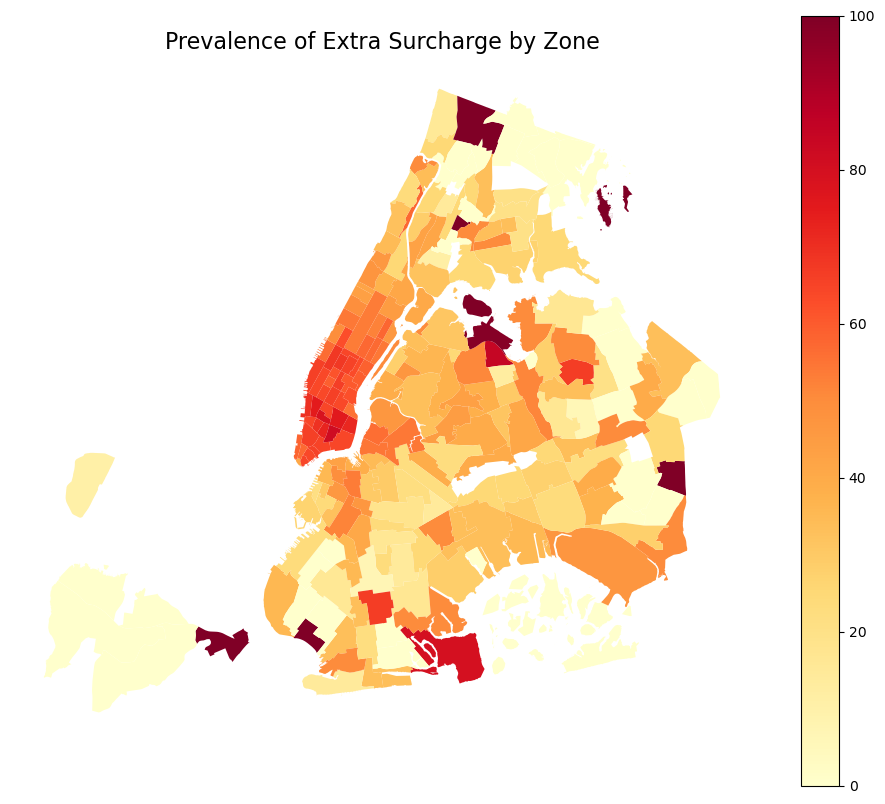

In [260]:
zones_extra = zones.merge(extra_by_zone, left_on="LocationID", right_on="PULocationID", how="left")

fig, ax = plt.subplots(1, 1, figsize=(12,10))
zones_extra.plot(column="extra", cmap="YlOrRd", legend=True, ax=ax)
ax.set_title("Prevalence of Extra Surcharge by Zone", fontsize=16)
ax.axis("off")
plt.show()


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.